## Συντελεστές Εργασίας 

* Σωκράτης Παπαργυρης sdi2200277
* Ανδρέας Παπαγεωργίου sdi1800146

### Διαδικαστικά 
- Όλα τα ερωτήματα έχουν απαντηθεί και σε κάθε ερώτημα  υπάρχει σχετική αρίθμηση και τίτλος
- Για κάθε ερώτημα έχουμε παραγράφους με markdown και latex εξηγόντας πως εργαστήκαμε καθώς και τις παρατηρήσεις και τον σχολιασμό των αποτελεσμάτων
για όλα τα ερωτήματα
- Παρόλο που το notebook έχει τρέξει με  τα αποτελέσματα (επειδή δίνουμε μόνο το notebook όπως λέει η εκφώνηση) 
αν θέλετε να το τρέξετε και εσείς μπορείτε να κάνετε τα ακόλουθα. 
- Σε ένα φάκελο data μπορείτε να βάλετε τα δεδομένα όπως δίνονται στο eclass.
- Επίσης έχουμε κάποια cells  με εντολές (σε σχόλια) ώστε να γίνουν install τα libraries αν δεν τα έχετε.  
- Επίσης έχουμε φτιάξει ένα αρχείο με τα BERT embeddings καθώς το encoding αργεί (~30min) για πολλά δεδομένα 
οπότε μιλάμε για την περίπτωση που αν θέλετε να το τρέξετε και εσείς στείλτε μας email στον ιδρυματικό λογαριασμό
να σας δώσουμε το αρχείο με τα embeddings ή το φάκελο με όλο το project.  




# Μέρος Α 
- Σε αυτή την παράγραφο έχουμε το πρώτο μέρος της εργασίας 
- Συνεχίζουμε το δεύτερο μέρος μετά το πρώτο χρησιμοποιώντας το ίδιο Notebook για ευκολία 

## 1.Συλλογή Δεδομένων (Data collection)
###  1A.Συλλογή Δεδομένων (Data collection)

- Σε αυτό το cell απλά διαβάζουμε ολα  αρχεία χρησιμοποιώντας το pandas library δημιουργώντας data_frames 
- Στην συνέχεια γίνεται join γίνεται με βάση του id όμως στην περίπτωση που το id δεν υπάρχει σε κάποιο data frame 
(Audio Stats, Lyrics, Genre) δεν το κρατάμε. 


In [2]:
import os
from pathlib import Path
import tarfile
import pandas as pd


""" Εδώ έχουμε ένα utility function το οποίο φορτώνει τα lyrics. """
""" Αυτό το function διαβάζει σειριακά τα αρχεία και φτιάχνει ένα ανάλογο dataframe με τα id και τα lyrics """

def fetch_lyrics(LYRICS_PATH) -> pd.DataFrame:
    lyrics_list = []

    try:
        with tarfile.open(LYRICS_PATH, "r") as tar:
            # Διαβάζουμε κάθε αρχείο μέσα στο tar
            for member in tar.getmembers():
                if member.isfile() and member.name.endswith(".txt"):
                    f = tar.extractfile(member)
                    content = f.read().decode('utf-8').strip()
                    # Το id είναι το όνομα του αρχείου χωρίς το .txt
                    song_id = Path(member.name).stem 
                    lyrics_list.append({'id': song_id, 'lyrics': content})
        return pd.DataFrame(lyrics_list)
    except Exception as e:
        print(f"Σφάλμα κατά την ανάγνωση του tar: {e}")
        return pd.DataFrame(columns=['id', 'lyrics'])
            
    
    



""" Η συνάρτηση αυτή φορτώνει το αρχικό data set. """
""" Αν κάποιο id δεν υπαρχει σε κάποιο αρχείο μπαίνει NaN για αυτό το attribute. """

def fetch_ds(DATA_DIR) -> pd.DataFrame:
    
    GENRES_PATH =  DATA_DIR / "id_genres.csv"
    INFO_PATH = DATA_DIR / "id_information.csv"
    AUDIO_PATH = DATA_DIR / "id_mfcc_stats.tsv.bz2"
    TAGS_PATH = DATA_DIR / "id_tags.csv"
    LYRICS_PATH = DATA_DIR / "processed_lyrics.tar.gz"
    
    try:
        genres_df = pd.read_csv(GENRES_PATH, sep='\t', engine='c') # φορτωση των genres
        info_df = pd.read_csv(INFO_PATH, sep='\t', engine='c')     # φορτωση των info
        tags_df = pd.read_csv(TAGS_PATH, sep='\t', engine='c')     # φορτωση των tags
        audio_df = pd.read_csv(AUDIO_PATH, sep='\t', engine='c')  # φορτωση των audio data 
        lyrics_df = fetch_lyrics(LYRICS_PATH)

        # Κανουμε join τα data sets κραταμε μόνο τα id για τα οποία έχουμε δεδομένα 
        # και στα 3 αρχεία (Audio Stats, Lyrics, Genre)
        df = ( 
              genres_df.merge(info_df, on='id', how='inner')
              .merge(tags_df, on='id', how='left')
              .merge(audio_df, on='id', how='inner')
              .merge(lyrics_df, on='id', how='inner')
            )
    
    except Exception as e:
        print(f"Προέκυψε σφάλμα κατά τη φόρτωση: {e}")
        return None
        
    return df

# φορτωνουμε και τυπωνουμε το dataset στην αρχική του μορφή
ds = fetch_ds(Path(os.getcwd()) / "data")   
ds

,id,genres,artist,song,album_name,tags,MFCC000,MFCC001,MFCC002,MFCC003,...,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12,lyrics
0,0009fFIM1eYThaPg,pop,Cheryl,Rain on Me,3 Words,"pop,british,female vocalists,dance,cheryl cole",23.622419,-14.435319,-7.964634,-4.066164,...,21.577481,2.908798,-6.870236,116.923098,21.549632,0.300939,110.923613,24.561615,96.538287,sunni day get nowher hide cloud sky pretend ge...
1,0010xmHR6UICBOYT,underground hip hop,Oddisee,After Thoughts,The Beauty in All,"instrumental hip-hop,underground hip hop,instr...",23.455795,11.819536,-21.976227,-4.329084,...,90.984262,25.687049,-8.231207,215.255758,87.617051,-38.538579,113.260527,4.126726,123.044429,may think word gift wrap put posit spin world ...
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock",Blue Öyster Cult,ME 262,Secret Treaties,"hard rock,rock,classic rock,american artist",22.909323,-7.674675,-19.895458,1.233454,...,46.560995,23.668015,15.582351,95.043195,42.135654,15.282257,120.657505,73.015982,122.500418,goer phone freiburg say willi do quit job hitl...
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal",Rhapsody,Flames of Revenge,Legendary Years (Re-Recorded),"symphonic metal,power metal,symphonic power metal",23.307997,-8.152816,-17.380590,-2.183497,...,42.409564,-1.556333,-20.841831,110.636928,59.997899,26.583978,108.297542,67.196903,108.900752,princess must assist death endur tragic pain c...
4,007LIJOPQ4Sb98qV,"post-punk,new wave",The Chameleons,Nostalgia,What Does Anything Mean? Basically (2009 Remas...,"post-punk,new wave,1985",22.255495,-13.936695,-8.608196,6.502494,...,20.351994,-8.587732,-15.062216,52.363672,13.583766,-4.626922,51.612082,20.294360,55.299642,absorb word battl rage within absorb word grad...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109264,zzyyPUs7hC9Nz2e1,"hardcore punk,punk,hardcore",Frank Carter & The Rattlesnakes,Vampires,Modern Ruin,"hardcore punk,punk,hardcore,punk rock",24.395718,-13.496446,-7.439415,5.599024,...,24.684697,-1.367185,-1.709222,68.362070,30.933606,4.268612,78.732114,32.089281,64.552076,cut heart cold ground stand like tombston lie ...
109265,zzz0n04uuTUA7fNh,pop,Justin Bieber,Heartbreaker,Journals,"pop,&lt;3,omg",22.753464,-7.968619,-8.176929,-8.593842,...,74.171706,39.665251,28.842650,156.010919,81.070001,33.351300,144.325860,57.157115,119.492892,girl know feel realli feel sinc away oh babi c...
109266,zzzj3LYaZtYtbzSr,singer-songwriter,Regina Spektor,Après Moi - Live In London,Live In London,"female vocalists,indie,singer-songwriter,piano...",22.580423,1.434257,-9.965219,0.207949,...,-26.851788,32.767341,-34.185107,149.752876,-53.989406,14.176133,168.021565,-57.695574,123.895321,wwi oh must go stand break oh must go stand ch...
109267,zzznMjZAKnJJXQSj,"synthpop,remix,pop",Dua Lipa,New Rules (Initial Talk Remix),New Rules (Initial Talk Remix),"synthpop,80s,remix,pop",23.685066,-13.454886,-6.107835,-6.073120,...,20.901035,4.866957,-8.136623,93.178975,16.851092,-6.463563,70.661701,16.337832,68.465345,talkin sleep night makin crazi mind mind write...


### 1Β. Φιλτράρισμα των δεδομένων 

-Σε αυτό το κελί φιλτράρουμε τα attributes των τραγουδιών ως εξής

#### Α Καθαρισμός genres 
- Αρχικά καθαρίζουμε το data set ως προς το είδος του τραγουδιού (genre) ώστε τα διαφορετικά γραμμένα είδη που 
έχουν ίδια μορφή να θεωρούνται ως ένα είδος αφαιρώντας τους ενδιάμεσους χαρακτήρες ανάμεσα στις λέξεις.
(π.χ. αγνοούμε το - και το / ωστε hip-hop το hip/hop να θεωρούνται ως ένα είδος)
Στην συνέχεια αφαιρούμε και τα διπλότυπα είδη ώστε να μην τα διπλομετρήσουμε. 

#### B Φιλτράρισμα τραγουδιών & τρόποι φιλτραρίσματος 

- Αρχικά επιλέγουμε μόνο τα τραγούδια που ανήκουν στα 5 πιο συχνά μουσικά είδη (Top-5 Genres) όπως προκύπτουν από το id_genres.csv. 
Αυτά είναι τα εξής ['rock', 'pop', 'electronic', 'alternative rock', 'indie rock'].

- Παρόλα αυτά αν θέλουμε να έχουμε μια πληθώρα τραγουδιών  ως προς το μέγεθος και το  είδος θα πρέπει να μην εχουμε υποείδη όπως το alternative rock και το 
rock μονο και μονο επειδή το rock έχει μεγαλύτερο support στα δεδομένα μας αποκλείωντας μια μεγάλη γκάμα τραγουδιών.

- Για αυτό τον λόγο βρίσκουμε τα top 10 είδη που είναι 
['rock', 'pop', 'electronic', 'alternative rock', 'indie rock', 'metal', 'folk', 'singer songwriter', 'classic rock', 'soul'] 
και από αυτά κρατάμε τα τραγούδια που είναι στα top 5 καθαρά είδη (genres) δηλαδή τα εξής ['rock', 'pop', 'electronic', 'metal', 'folk'] 
 
- Γενικά μπορούμε να επιλέξουμε αρκετούς τρόπους με τους οποίους μπορούμε να κάνουμε το φιλτράρισμα των τραγουδιών. 
Ένας τρόπος είναι να επιλέξουμε τραγούδια που ανήκουν αυστηρά στο top 5 genre και σε κανένα άλλο είδος (πχ μονο rock η μονο rock, electronic κοκ) κοβοντας 
ενα σημαντικο πλήθος τραγουδιων.

- Ένας άλλος τρόπος είναι να μην εφαρμόσουμε κάποιον τέτοιο περιορισμό και να πάρουμε τα τραγούδια που απλά αναφέρουν κάποιο από τα top 5 στο είδος 
επιλέγοντας αρκετά περισσότερα τραγούδια.Εμείς αυτό εφαρμόσαμε κρατώντας αρκετά περισσότερα τραγούδια επειδή ζητάμε να έχουμε δεδομένα και για τον
αλγόριθμο στην συνέχεια. Επίσης η εκφώνηση ζητάει plot σχετικά με το πλήθος των genres (πχ πάνω από 10 κοκ) αρα θεωρήσαμε σωστό να φιλτράρουμε με
αυτόν τον τρόπο



-Προσοχή!! Δεν κανονικοποιούμε τα audio attributes σε αυτό το στάδιο (ή αν το κάνουμε πρέπει με πολύ προσοχή)  
ακόμα και αν ο αλγόριθμος το απαιτεί (γιατί ? δείτε την παρατήρηση )

- Όσο αναφορά τα υπόλοιπα αλφαριθμητικά attributes  η επεξεργασια που θα μπορούσε να γίνει εδώ 
είναι η επεξεργασία/αφαιρεση των  stop words, punctuation,lemmatization, etc αυτά όμως δεν χρειάζονται
να γίνουν σε αυτό το στάδιο αλλά μπορούν να γίνουν είτε κατα την δημιουργία των word embeddings (vectorization) περνώντας 
τα κατάλληλα ορίσματα είτε ως υπερπαράμετρους όταν κάνουμε grid-search με σκοπό να συγκρίνουμε την 
απόδοση του αλγορίθμου με η χωρίς αυτά (δείτε παρατήρηση link). 

- Σχετικά με τα audio attributes τρεχοντας ενα python script ειδαμε ότι δεν υπάρχουν κενά ή NaN. 
Επίσης τα τραγούδια που δεν υπάρχουν στοίχοι δεν τα φιλτράρουμε γιατί η ασκηση ζηταει οπτικοποίηση στο 3.  

##### Σημαντική Παρατήρηση σχετικά με το scaling !!!

- O pca αλγόριθμος κανονικοποιεί τα features πρωτού τα επεξεργαστεί 

- Ας πούμε ότι χρησιμοποιούμε τη συνάρτηση της βιβλιοθήκης StandardScaler, η οποία χρησιμοποιεί  standardization για να εκτελέσει την κλιμάκωση, οπότε η κανονικοποιημένη τιμή είναι:
                            $$z = \frac{x - \mu}{\sigma}$$
όπου $\mu = \mathbb{E}[X]$ η μέση τιμή  και $\sigma^2 = \mathbb{V}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$ η τυπική απόκλιση (σ)

- Το πρόβλημα είναι ότι στη συνέχεια στο δεύτερο μέρος  πρέπει να εκτελέσουμε k-cross validation. 
  Άρα αν κάνουμε prescaling από τώρα τα χαρακτηριστικά μας, χρησιμοποιούμε την μέση τιμή $\mu_{train}$ 
  και την τυπική απόκλιση $\sigma_{train}$ του train set.
- Αργότερα όμως εκτελούμε k-cross validation πράγμα που σημαίνει ότι επιλέγουμε ένα υποσύνολο του train set για να παίξει 
το ρόλο του validation set

- Αυτό όμως είναι κλεψιά  (cheating) επειδή (άθελά μας) έχουμε "πικάρει" το validation set με τους μέσους όρους ( και ακόμα χειρότερα ίσως το test_set αν παμε να το κανουμε σπλιτ) , 
υπονομεύοντας τα αποτελέσματα του validation (ή του test) και προκαλώντας μια πιθανή διαρροή δεδομένων (data leak).Αυτό μπορεί να διορθωθεί αν πχ δώσουμε τον έλεγχο στο library δημιουργώντας
ενα pipeline εφαρμοζοντας τον scaler  εκει κάπως έτσι πχ 

https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#sphx-glr-auto-examples-compose-plot-column-transformer-mixed-types-py

- Attributes τα οποία προκαλούν θόρυβο ή data leaks θα αφαιρεθούν στο επόμενο σκέλος αν χρειάζεται καθως και το split στο test set αν δεν εχουμε καινουριο! 

In [3]:
import re
from collections import Counter


##################################################################################################
######################## Utilities ###############################################################
##################################################################################################


"""" Utility function που καθαρίζει το genre attribute αφαιρώντας τα
περιττά σύμβολα από τα είδη (π.χ. hip-hop ή hip/hop -> hip hop ) καθώς και τα  διπλότυπα είδη 
ανά τραγούδι. """
def clean_genres(genre_str) -> str:
    if pd.isna(genre_str):
        return []
    
    # 1. Μετατροπή σε πεζά και διαχωρισμός με βάση το κόμμα
    raw_list = genre_str.lower().split(',')
    
    clean_list = []
    for g in raw_list:
        # 2. Αφαίρεση συμβόλων (π.χ. hip-hop -> hip hop) και περιττών κενών
        g_clean = re.sub(r'[^a-zA-Z0-9\s]', ' ', g).strip()
        # Κανονικοποίηση κενών (πολλά κενά -> ένα)
        g_clean = " ".join(g_clean.split())
        if g_clean:
            clean_list.append(g_clean)
            
    # 3. Αφαίρεση διπλοτύπων μέσα στο ίδιο το τραγούδι
    clean_list = list(set(clean_list))
    return ", ".join(clean_list) # επεστρεψε το αντιστοιχο string 



"""" Utility function το οποίο επιστρέφει μια λίστα με  τα 5 πιο συχνά είδη  """
def select_top_genres(ds, n) -> list: 
    all_genres = [g.strip() for sublist in ds['genres'].str.split(',') for g in sublist if g] # flatten ολα τα genres (τωρα είναι μοναδικά)
    return  [name for name, count in Counter(all_genres).most_common(n)] # επιστροφή των n top ονομάτων 

"""Utility function στο οποίο κρατάμε όλα τα τραγούδια που απλά αναφέρουν κάποιο από τα top 5 στο είδος τους
επιλέγοντας αρκετά περισσότερα τραγούδια αλλά επιστρέφει μόνο το πρώτο είδος που ανήκει στα top_5  θεωρόντας το 
ως το βασικό είδος του τραγουδιού. """
def filter_genres(s, top_5_genres)-> str: 
    filtered = [g.strip() for g in s.split(',') if g.strip() in top_5_genres] # Κρατάμε όλα τα τραγούδια που απλά αναφέρουν κάποιο από τα top 5 στο είδος τους
    
    # Θεωρούμε το πρώτο είδος από αυτά που είναι στα top 5 ως βασικό 
    # Αν η λίστα είναι άδεια επιστρέφουμε "" και το τραγούδι θα διαγραφτεί 
    if filtered:
        return filtered[0] 
    else:
        return ""


# """Utility function στο οποίο κρατάμε όλα τα τραγούδια που απλά αναφέρουν κάποιο από τα top 5 στο είδος τους
# επιλέγοντας αρκετά περισσότερα τραγούδια αλλά επιστρέφει μόνο το πρώτο είδος που ανήκει στα top_5  θεωρόντας το 
# ως το βασικό είδος του τραγουδιού. """
# def filter_genres(s, top_5_genres)-> str: 
#     filtered = [g.strip() for g in s.split(',') if g.strip() in top_5_genres] # Κρατάμε όλα τα τραγούδια που απλά αναφέρουν κάποιο από τα top 5 στο είδος τους
#     return ", ".join(filtered)



  

    

"""Utility function που φιλτράρει το dataset διαγράφωντας τα 
τραγούδια που δεν είναι στα τοπ 5 genres """
def genre_filter(df) -> pd.DataFrame:
    filtered_df = df[df['top_genres'] != ""].copy()  # Φιλτράρισμα: Κρατάμε όσα δεν είναι κενά στη νέα στήλη
    filtered_df = filtered_df.reset_index(drop=True)  # Διόρθωση του Index μετά τη διαγραφή    
    return filtered_df


def clean_dataset(ds) -> pd.DataFrame:
    ds['genres'] = ds['genres'].apply(clean_genres)
    # εδώ  ζητάμε τα 5 καλύτερα είδη αλλά θέλουμε τα 5 καλύτερα "καθαρά" είδη τα οποία τα έχω hardcoded 
    # top_5_genres = select_top_genres(ds, 5) 
    # print(top_5_genres)
    top_5_genres = ['rock', 'pop', 'electronic', 'metal', 'folk'] # εδώ τα ορίζουμε χεράτα τα 5 καλύτερα "καθαρά" είδη χωρίς υποκατηγορίες
       
    # Φιλτράρουμε τα τραγούδια αν ανήκουν στα κορυφαία είδη 
    # Δημιουργούμε νέο attribute με τα είδη για αυτό το τραγούδι που επιλέχθηκαν ως κορυφαία
    ds['top_genres'] = ds['genres'].apply(lambda x: filter_genres(x, top_5_genres))
    ds = genre_filter(ds)
    return ds

ds = clean_dataset(ds)
ds



,id,genres,artist,song,album_name,tags,MFCC000,MFCC001,MFCC002,MFCC003,...,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12,lyrics,top_genres
0,0009fFIM1eYThaPg,pop,Cheryl,Rain on Me,3 Words,"pop,british,female vocalists,dance,cheryl cole",23.622419,-14.435319,-7.964634,-4.066164,...,2.908798,-6.870236,116.923098,21.549632,0.300939,110.923613,24.561615,96.538287,sunni day get nowher hide cloud sky pretend ge...,pop
1,002Jyd0vN4HyCpqL,"hard rock, classic rock, rock",Blue Öyster Cult,ME 262,Secret Treaties,"hard rock,rock,classic rock,american artist",22.909323,-7.674675,-19.895458,1.233454,...,23.668015,15.582351,95.043195,42.135654,15.282257,120.657505,73.015982,122.500418,goer phone freiburg say willi do quit job hitl...,rock
2,00DZ3XCAQb2FdCc6,"easy listening, electronic, ambient",Gold Panda,Same Dream China,Lucky Shiner,"ambient,mellow,instrumental,easy listening,ele...",24.707487,-4.001090,-5.915417,-2.047395,...,-5.127912,-4.525168,140.849103,64.715301,3.184150,164.062654,76.440046,123.405133,,electronic
3,00IeldeA9ijZOL0P,"pop, disney",The Cheetah Girls,One World,The Cheetah Girls: One World,"pop,bollywood,one world,disney",21.568781,-13.389622,-8.882600,-0.269254,...,22.861579,31.183207,147.867776,51.391861,2.443206,122.146749,39.369417,139.240961,yeah yeah love alway find way everi singl time...,pop
4,00KSCJkYb8JKa4Y3,"emo, rock",Annisokay,Coma Blue,Arms,"rock,german,progressive,emo",24.403093,-16.733761,-8.509400,2.593060,...,2.314420,-0.867733,65.294129,32.377812,10.575304,71.358262,34.404783,61.722595,fuck nobodi anybodi somebodi nobodi anybodi on...,rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60450,zzoFYDMlqU1X2zz1,"electronic, soul, jazz, funk",Thundercat,DUI,Drunk,"funk,electronic,soul,jazz,2017,psychedelic",23.589041,5.548734,-11.543346,1.929287,...,25.641715,11.663813,104.258840,19.508697,2.376660,112.588410,14.291778,77.147589,sometim aliv sometim dead insid time read line...,electronic
60451,zzqNN6leHep4q1K7,"folk, j pop, soundtrack, pop",Kalafina,ring your bell,Kalafina All Time Best 2008-2018,"j-pop,folk,jpop,pop,soundtrack,japan",23.046219,-13.083031,-10.684020,5.893723,...,-1.320155,0.351225,92.052677,26.733644,-1.074541,81.600392,35.390099,70.055777,heart disappear someday least far voic want si...,folk
60452,zzz0n04uuTUA7fNh,pop,Justin Bieber,Heartbreaker,Journals,"pop,&lt;3,omg",22.753464,-7.968619,-8.176929,-8.593842,...,39.665251,28.842650,156.010919,81.070001,33.351300,144.325860,57.157115,119.492892,girl know feel realli feel sinc away oh babi c...,pop
60453,zzznMjZAKnJJXQSj,"remix, synthpop, pop",Dua Lipa,New Rules (Initial Talk Remix),New Rules (Initial Talk Remix),"synthpop,80s,remix,pop",23.685066,-13.454886,-6.107835,-6.073120,...,4.866957,-8.136623,93.178975,16.851092,-6.463563,70.661701,16.337832,68.465345,talkin sleep night makin crazi mind mind write...,pop


In [4]:

counts = ds['top_genres'].value_counts()
with pd.option_context('display.max_rows', None):
    print(counts)
    print(counts.sum())
    
    



# μικρά scripts που ελεγχουν για διπλοτυπα τραγουδια ή NaN ή κενά στις στήλες 
# για να δούμε αν χρειάζετε παραπάνω επεξεργασία 


# duplicates_count = ds['id'].duplicated().sum()
# print(f"Βρέθηκαν {duplicates_count} διπλότυπα IDs.")
# blanks_per_column = (ds.isna()) | (ds.astype(str).apply(lambda x: x.str.strip()) == "")

# # Εκτύπωση της λίστας ανά στήλη
# with pd.option_context('display.max_rows', None):
#     print("--- Λίστα κενών ανά στήλη ---")
#     print(blanks_per_column.sum())

# #  Εκτύπωση του συνολικού αθροίσματος

# total_blanks = blanks_per_column.sum().sum()
# print("\n------------------------------")
# print(f"Συνολικό άθροισμα κενών στο DataFrame: {total_blanks}")





top_genres
rock          20490
pop           19140
electronic     9888
folk           5483
metal          5454
Name: count, dtype: int64
60455


## 2.Εξαγωγή Χαρακτηριστικών & Embeddings (Feature Extraction)


### A. Εκπαίδευση Word2Vec για τα lyrics 

- Όπως έχουμε δει ένα word2vec μοντέλο εκπαιδεύει διανύσματα για κάθε λέξη και όχι ολόκληρο το κείμενο.
Ομως ο αλγόριθμός μας στο μέρος 2 ζητάει ένα διάνυσμα ανά τραγούδι.

- Έτσι παίρνουμε την μέση τιμή  των Word Vectors όλων των λέξεων που περιέχει το εκάστοτε τραγούδι.
Αυτός ο μετασχηματισμός μας βοηθάει να φέρουμε το data set στην κατάλληλη μορφή για εκπαίδευση. 

- Σημείωση: Επειδή θέλουμε τα τραγούδια χωρίς lyrics για την άσκηση 3 το μετασχηματίζουμε σε διανυσμα με μηδενικά 

- Σημείωση: Αν δεν έχετε κάνει install το library της gensim pip install gensim

In [4]:
# pip install gensim

In [5]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec


w2v_ds = ds.copy()

w2v_ds['lyrics'] = w2v_ds['lyrics'].fillna("").apply(lambda x: x.split()) # NaN -> ""
sentences = w2v_ds['lyrics'].tolist() #Περνάμε στο μοντέλο όλες τις λίστες λέξεων 

# Αρχικοποίηση του μοντέλου 
vec_size = 100
w2v_model = Word2Vec (
    sentences=sentences, 
    vector_size=vec_size, 
    window=5, 
    min_count=1, 
    workers=4
)



"""Εδώ έχουμε ένα utility function το οποίο κάνει τον μετασχηματισμό που αναφέραμε πιο πάνω
παίρνωντας την μέση τιμή  των Word Vectors όλων των λέξεων που περιέχει το κάθε τραγούδι. """
def expected_value_transformation(tokens, model, vector_size):
    # Κρατάμε τις λέξεις που έχει  το μοντέλο
    valid_words = [word for word in tokens if word in model.wv.key_to_index]
    
    # Όπως είπαμε παραπάνω  αν υπάρχουν κενά τα μετασχηματίζουμε σε διανύσματα που εχουν μηδενικά  
    if len(valid_words) == 0:
        return np.zeros(vector_size) # Επιστρέφει ένα διάνυσμα με μηδενικά π.χ. [0.0, 0.0, ..., 0.0]
    
    # Υπολογισμός της μέσης τιμής  των διανυσμάτων των λέξεων του τραγουδιού
    word_vectors = [model.wv[word] for word in valid_words]
    return np.mean(word_vectors, axis=0)


# Εδώ μετασχηματίζουμε το αρχικό dataset στο νέο dataset το οποίο σπάει τα στοιχεία των διανυσμάτων σε χαρακτηριστικά 
w2v_ds['lyrics_vector'] = w2v_ds['lyrics'].apply(lambda x: expected_value_transformation(x, w2v_model, vec_size))
transformed_ds = pd.DataFrame(w2v_ds['lyrics_vector'].tolist(), index=w2v_ds.index)
transformed_ds = transformed_ds.add_prefix('w2v_feature_')
w2v_based_ds = pd.concat([w2v_ds, transformed_ds], axis=1)
w2v_based_ds.drop(columns=['lyrics', 'lyrics_vector'], inplace=True)
w2v_based_ds



,id,genres,artist,song,album_name,tags,MFCC000,MFCC001,MFCC002,MFCC003,...,w2v_feature_90,w2v_feature_91,w2v_feature_92,w2v_feature_93,w2v_feature_94,w2v_feature_95,w2v_feature_96,w2v_feature_97,w2v_feature_98,w2v_feature_99
0,0009fFIM1eYThaPg,pop,Cheryl,Rain on Me,3 Words,"pop,british,female vocalists,dance,cheryl cole",23.622419,-14.435319,-7.964634,-4.066164,...,-0.310095,0.274233,-0.242949,-0.493748,-0.647348,-0.626353,-0.325627,1.302129,0.436914,-0.034198
1,002Jyd0vN4HyCpqL,"hard rock, classic rock, rock",Blue Öyster Cult,ME 262,Secret Treaties,"hard rock,rock,classic rock,american artist",22.909323,-7.674675,-19.895458,1.233454,...,-0.481261,0.010945,-0.046098,0.008106,-0.427097,-0.143260,-0.054875,0.443495,0.024715,-0.197703
2,00DZ3XCAQb2FdCc6,"easy listening, electronic, ambient",Gold Panda,Same Dream China,Lucky Shiner,"ambient,mellow,instrumental,easy listening,ele...",24.707487,-4.001090,-5.915417,-2.047395,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,00IeldeA9ijZOL0P,"pop, disney",The Cheetah Girls,One World,The Cheetah Girls: One World,"pop,bollywood,one world,disney",21.568781,-13.389622,-8.882600,-0.269254,...,-0.664716,0.906442,0.243347,-0.731154,-1.448222,-0.438898,-0.057235,1.253754,0.358996,-0.797355
4,00KSCJkYb8JKa4Y3,"emo, rock",Annisokay,Coma Blue,Arms,"rock,german,progressive,emo",24.403093,-16.733761,-8.509400,2.593060,...,-0.090492,0.855207,0.250938,-0.198730,-0.575167,-0.319210,0.089366,1.463754,0.072804,-0.401831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60450,zzoFYDMlqU1X2zz1,"electronic, soul, jazz, funk",Thundercat,DUI,Drunk,"funk,electronic,soul,jazz,2017,psychedelic",23.589041,5.548734,-11.543346,1.929287,...,-0.764551,0.574269,-0.191411,0.069635,-0.691371,-0.853787,-0.355373,1.349638,-0.184907,-0.924126
60451,zzqNN6leHep4q1K7,"folk, j pop, soundtrack, pop",Kalafina,ring your bell,Kalafina All Time Best 2008-2018,"j-pop,folk,jpop,pop,soundtrack,japan",23.046219,-13.083031,-10.684020,5.893723,...,-0.085174,0.114787,0.003030,-0.097428,-0.823321,-0.421648,-0.457260,0.758773,0.017315,-0.473507
60452,zzz0n04uuTUA7fNh,pop,Justin Bieber,Heartbreaker,Journals,"pop,&lt;3,omg",22.753464,-7.968619,-8.176929,-8.593842,...,-0.551042,0.475939,-0.009868,-0.295016,-0.555708,-0.731248,0.073124,1.409271,0.676669,-1.016839
60453,zzznMjZAKnJJXQSj,"remix, synthpop, pop",Dua Lipa,New Rules (Initial Talk Remix),New Rules (Initial Talk Remix),"synthpop,80s,remix,pop",23.685066,-13.454886,-6.107835,-6.073120,...,-0.744096,0.295630,0.114251,-0.123495,-0.688166,-0.483557,0.194800,1.188710,-0.022651,-0.627839


### B.  BERT-based sentence transformers (BONUS για lyrics embeddings)
Λιγα λογια για το BERT
- Εδώ χρησιμοποιούμε όπως λέει η εκφώνηση ένα προεκπαιδευμένο embedding από την google το BERT.
- Τετοια είδους μοντέλα προ εκπαιδεύονται σε παραπολλές προτάσεις χρησιμοποιώντας Masked Language Modeling δηλαδή κρύβεται η λέξη 
και προσπαθούμε να την βρούμε 
- Χρησιμοποιεί τον μηχανισμό Attention δηλαδή κοιτάζει ταυτόχρονα όλες τις λέξεις της πρότασης για να καταλάβει το νόημα της κάθε μίας ξεχωριστά.

-Άρα η κύρια  διαφορά του με το word2vec είναι  δυναμικό δηλαδή ίδιες λέξεις σε διαφορετικό context θα έχουν τελείως διαφορετικά διανύσματα. 

- Εμείς φορτώνουμε ένα πολύ ελαφρύ μοντέλο.Το SBERT (Sentence-BERT) παίρνει ολόκληρο το κείμενο του τραγουδιού και  βγάζει το 
ζητούμενο διάνυσμα χωρίς να κάνουμε κάποιον χεράτο μετασχηματισμό με τους μέσους όρους όπως την προηγούμενη περίπτωση. 

- Αν θέλετε να το τρέξετε και δεν το έχετε κάνει install τότε pip install sentence-transformers (παίρνει λίγη ώρα )
αλλιώς αν τίποτα δεν δουλεύει δοκίμαστε 

- Το encoding για ~60.000 τραγούδια απαιτεί ~30min για αυτό τα αποθηκεύουμε σε ένα αρχείο ωστε να τα παίρνουμε από εκεί κάθε φορά
χρησιμοποιώντας ένα utility function.

- Προσοχή για κάθε αλλαγή στα δεδομένα το encoding πρέπει να επαναληφθεί.




In [6]:
# 2. Εγκατάσταση συγκεκριμένων εκδόσεων που ξέρουμε ότι δουλεύουν
# %pip uninstall -y transformers sentence-transformers huggingface-hub tokenizers
# %pip install transformers==4.30.2 sentence-transformers==2.2.2 huggingface-hub==0.15.1

In [6]:
# from sentence_transformers import SentenceTransformer
import transformers
import sentence_transformers
from sentence_transformers import SentenceTransformer

"""Επειδή αν έχουμε πολλά τραγούδια το encoding των BERT embeddings είναι μια  πολλαπλασιαστικά αργή διεργασία 
τα αποθηκεύουμε σε ένα αρχείο και τα φορτώνουμε από εκεί σε περίπτωση που υπάρχει το αρχείο στο path διαφορετικά κάνουμε
το encoding :) """
def fetch_bert_embeddings(FILE_PATH): 
    if os.path.exists(FILE_PATH):
        print("Το αρχείο βρέθηκε! Φόρτωση BERT embeddings...")
        embeddings = np.load(FILE_PATH)
        print("Φορτώθηκαν", embeddings.shape, "embeddings.")
    else:
        print("Το αρχείο δεν υπάρχει. Ξεκινάει το encoding (αναμονή)...")
        # Εδώ τρέχει το μοντέλο σου
        embeddings = model.encode(sentences, show_progress_bar=True)
        # Αποθήκευση για την επόμενη φορά
        np.save(FILE_PATH, embeddings)
        print("Το encoding ολοκληρώθηκε και το αρχείο σώθηκε!")
    
    return  embeddings



bert_based_ds = ds.copy()
model = SentenceTransformer('all-MiniLM-L6-v2') # Φόρτωση  BERT-based sentence transformer
sentences = bert_based_ds['lyrics'].fillna("").tolist() # Τα κενά κελιά θα γίνουν κενά strings για να μην βγάλει σφάλμα
embeddings = fetch_bert_embeddings('lyrics_bert_embeddings.npy') # fetch bert embeddings με το utility function 

embeddings_df = pd.DataFrame(embeddings, index=bert_based_ds.index)
embeddings_df = embeddings_df.add_prefix('bert_feature_')

bert_based_ds = pd.concat([bert_based_ds.drop(columns=['lyrics']), embeddings_df], axis=1)
print("Το dataset μετά την ενσωμάτωση των BERT embeddings είναι")
bert_based_ds 


Το αρχείο βρέθηκε! Φόρτωση BERT embeddings...
Φορτώθηκαν (60455, 384) embeddings.
Το dataset μετά την ενσωμάτωση των BERT embeddings είναι


,id,genres,artist,song,album_name,tags,MFCC000,MFCC001,MFCC002,MFCC003,...,bert_feature_374,bert_feature_375,bert_feature_376,bert_feature_377,bert_feature_378,bert_feature_379,bert_feature_380,bert_feature_381,bert_feature_382,bert_feature_383
0,0009fFIM1eYThaPg,pop,Cheryl,Rain on Me,3 Words,"pop,british,female vocalists,dance,cheryl cole",23.622419,-14.435319,-7.964634,-4.066164,...,-0.004629,0.072993,0.005452,0.026248,-0.023682,-0.002012,-0.011138,-0.083886,-0.028445,0.021516
1,002Jyd0vN4HyCpqL,"hard rock, classic rock, rock",Blue Öyster Cult,ME 262,Secret Treaties,"hard rock,rock,classic rock,american artist",22.909323,-7.674675,-19.895458,1.233454,...,-0.034319,0.027358,0.002476,-0.002438,0.008069,0.059954,0.119040,-0.070056,-0.075111,-0.039703
2,00DZ3XCAQb2FdCc6,"easy listening, electronic, ambient",Gold Panda,Same Dream China,Lucky Shiner,"ambient,mellow,instrumental,easy listening,ele...",24.707487,-4.001090,-5.915417,-2.047395,...,0.107304,0.011428,0.013367,-0.012747,0.061454,0.035641,0.158746,0.126409,0.046549,-0.015717
3,00IeldeA9ijZOL0P,"pop, disney",The Cheetah Girls,One World,The Cheetah Girls: One World,"pop,bollywood,one world,disney",21.568781,-13.389622,-8.882600,-0.269254,...,0.039827,0.051574,-0.036499,0.084020,0.047775,-0.005877,0.038711,-0.015109,0.066575,-0.089157
4,00KSCJkYb8JKa4Y3,"emo, rock",Annisokay,Coma Blue,Arms,"rock,german,progressive,emo",24.403093,-16.733761,-8.509400,2.593060,...,0.058667,-0.035845,-0.037084,0.106209,-0.045213,0.036835,0.051132,0.053385,0.008856,-0.039452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60450,zzoFYDMlqU1X2zz1,"electronic, soul, jazz, funk",Thundercat,DUI,Drunk,"funk,electronic,soul,jazz,2017,psychedelic",23.589041,5.548734,-11.543346,1.929287,...,0.064098,0.000105,0.030594,0.087566,-0.054751,0.039009,0.072553,0.023625,-0.010631,-0.035969
60451,zzqNN6leHep4q1K7,"folk, j pop, soundtrack, pop",Kalafina,ring your bell,Kalafina All Time Best 2008-2018,"j-pop,folk,jpop,pop,soundtrack,japan",23.046219,-13.083031,-10.684020,5.893723,...,0.048315,0.020649,0.013679,0.087061,-0.062588,-0.037579,0.027288,0.006358,0.010805,-0.009523
60452,zzz0n04uuTUA7fNh,pop,Justin Bieber,Heartbreaker,Journals,"pop,&lt;3,omg",22.753464,-7.968619,-8.176929,-8.593842,...,0.005005,0.054651,-0.024846,0.098696,-0.006472,0.026263,0.021596,0.031767,-0.035620,-0.032054
60453,zzznMjZAKnJJXQSj,"remix, synthpop, pop",Dua Lipa,New Rules (Initial Talk Remix),New Rules (Initial Talk Remix),"synthpop,80s,remix,pop",23.685066,-13.454886,-6.107835,-6.073120,...,0.077981,0.013031,-0.055824,0.077975,0.006976,0.004969,0.026257,0.071409,-0.036107,-0.062303


### Γ. PCA Audio Embeddings
- Σε αυτή την παράγραφο προσπαθούμε να δώσουμε μια συνοπτική περιγραφή του τι θέλουμε να πετύχουμε με την pca
και πως την εφαρμόσαμε. 

- Αυτή την στιγμή το dataset μας έχει πολλά audio features που κρατάνε πληροφορίες από το φάσμα του ήχου.
Όμως ενδεχομένως πολλά απο αυτά τα features μπορεί  να συσχετίζονται μεταξύ τους σκοπός μας είναι να συμπιέσουμε 
το σήμα μειώνοντας τα features του χωρίς όμως να αλλοιώσουμε τελείως την ουσία του σήματος δηλαδή η κάθε συνιστώσα 
που θα λάβουμε να μας δίνει μια τελείως νέα πληροφορία.

- Λογικά για να γίνει αυτό σωστά υποθέτουμε ότι το library θα πρέπει να φροντίσει να υπολογίσει συνιστώσες οι οποίες να είναι ορθογώνιες.
- Από ότι είδαμε το pca υπολογίζει το covariance των features ανα 2 (και με τον ευατό του δλδ το variance του ) μετρώντας την γραμμική τους σχέση,
κατασκευάζοντας έναν τετραγωνικό πίνακα της μορφής 

\[
\begin{bmatrix}
var_{f1} & covar_{f1f2} & \cdots & covar_{f1fn} \\
covar_{f2f1} & var_{f2} & \cdots & covar_{f2fn} \\
\vdots & \vdots & \ddots & \vdots \\
covar_{fnf1} & covar_{fnf2} & \cdots & var_{fn}
\end{bmatrix}
\]


- Για καλή μας τυχη ο πινακας αυτός πέρα απο τετραγωνικος ειναι και συμμετρικος αφού cov(f1,f2) = cov(f2,f1) αυτό μας 
βολεύει κυριως γιατι απο την αλγεβρα εχουμε οτι τα ιδιοδιανύσματα του (που εχουν διαφορετικες ιδιοτιμες) ειναι καθετα μεταξυ τους.
(Σημείωση: Το να έχουμε συμμετρικο πίνακα ίσως βολεύει και στον υπολογισμό των μεγαλύτερων ιδιοτιμών (και των αντιστοιχων ιδιοδιανυσματων) καθως εχουμε μεθοδους 
που συγκλινουν πιο γρήγορα πχ στην μεγαλύτερη ιδιοτιμη πχ Rayleigh κοκ)

- Σημείωση: Από ότι ψάξαμε το pca απαιτεί την κανονικοποίηση των features  πριν την επεξεργασία αλλά τα embeddings που επιστρέφει 
δεν είναι κανονικοποιημένα  οπότε δεν χρειάζετε να ανυσιχούμε για καποιο data leak όπως αναφέραμε στην προηγούμενη παρατήρηση.


#### Προβλημα Γραμμικότητας  

- Όπως προαναφέραμε το covariance μετράει την γραμμική σχέση των features.
- Παρολα αυτα όμως δυο features μπορεί να  σχετιζονται με μη γραμμικο τροπο.
- Ουσιαστικα μπορει ενα feature να εχει μικρο variance και παρόλα αυτα να ειναι αρκετά συμαντικό
και εμεις να το εχουμε πεταξει. 

- Η λύση σε αυτο το προβλημα ειναι αυτο που προτεινεται και εσεις  δλδ η εκπαίδευση ενος απλού νερονικού. 
  Αν θέλετε δείτε και την επόμενη παράγραφο 





In [7]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


"""Εδω εχουμε ενα utility function το οποιο παιρνει το dataset και επιστρέφει 
τα audio features κανονικοποιημένα γιατί το pca το απαιτεί """
def get_audio_features(ds): 
    features = [col for col in ds.columns if col.startswith('MFCC') or col.startswith('cov_')]
    audio_features = ds[features]
    
    scaler = StandardScaler()   # Κανονικοποίηση ΠΡΙΝ το PCA (Standardization)
    scaled_audio_features  = scaler.fit_transform(audio_features)
    return scaled_audio_features,features

w2v_pca_ds = w2v_based_ds.copy() 
scaled_audio_features, features = get_audio_features(w2v_based_ds)
pca = PCA(n_components=0.95)    # Κραταμε το 95% της διακύμανσης  
audio_embeddings = pca.fit_transform(scaled_audio_features)

num_of_components = audio_embeddings.shape[1]
embedding_col_names = [f'PCA_emb_{i+1}' for i in range(num_of_components)]


pca_ds = pd.DataFrame(audio_embeddings, columns=embedding_col_names, index=w2v_pca_ds.index)
w2v_pca_ds = pd.concat([w2v_pca_ds, pca_ds], axis=1)
w2v_pca_ds.drop(columns=features, inplace=True)
print("Το νέο data set με τα pca audio embeddings (και τα w2v lyric embeddings) είναι:")
w2v_pca_ds


Το νέο data set με τα pca audio embeddings (και τα w2v lyric embeddings) είναι:


,id,genres,artist,song,album_name,tags,top_genres,w2v_feature_0,w2v_feature_1,w2v_feature_2,...,PCA_emb_72,PCA_emb_73,PCA_emb_74,PCA_emb_75,PCA_emb_76,PCA_emb_77,PCA_emb_78,PCA_emb_79,PCA_emb_80,PCA_emb_81
0,0009fFIM1eYThaPg,pop,Cheryl,Rain on Me,3 Words,"pop,british,female vocalists,dance,cheryl cole",pop,0.501146,-0.786782,-0.474059,...,0.553046,0.677114,0.113911,0.040992,-0.341744,-0.032965,0.289108,0.071762,0.116486,-0.035654
1,002Jyd0vN4HyCpqL,"hard rock, classic rock, rock",Blue Öyster Cult,ME 262,Secret Treaties,"hard rock,rock,classic rock,american artist",rock,0.619187,-0.012828,0.165186,...,0.005525,0.593143,-0.363206,0.586037,-0.402756,0.406410,0.209124,-1.185690,-1.211142,-0.578615
2,00DZ3XCAQb2FdCc6,"easy listening, electronic, ambient",Gold Panda,Same Dream China,Lucky Shiner,"ambient,mellow,instrumental,easy listening,ele...",electronic,0.000000,0.000000,0.000000,...,0.026480,0.475412,-0.199246,1.404039,0.211597,1.154034,0.294757,1.475778,-2.114025,-2.195354
3,00IeldeA9ijZOL0P,"pop, disney",The Cheetah Girls,One World,The Cheetah Girls: One World,"pop,bollywood,one world,disney",pop,0.896865,0.159124,-0.511517,...,-0.953758,0.072576,-0.416766,0.133271,0.836547,0.710971,-0.256856,0.316697,-0.344000,0.034144
4,00KSCJkYb8JKa4Y3,"emo, rock",Annisokay,Coma Blue,Arms,"rock,german,progressive,emo",rock,0.591366,0.147315,-0.233260,...,0.172995,-0.015708,-0.039852,0.197371,0.270005,-0.170147,0.188972,0.051790,0.087103,0.286523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60450,zzoFYDMlqU1X2zz1,"electronic, soul, jazz, funk",Thundercat,DUI,Drunk,"funk,electronic,soul,jazz,2017,psychedelic",electronic,1.159664,-0.157088,-0.467924,...,0.245422,-0.283610,-0.333012,-0.816839,0.904807,-0.731472,-0.583616,-0.651754,0.324707,-0.022644
60451,zzqNN6leHep4q1K7,"folk, j pop, soundtrack, pop",Kalafina,ring your bell,Kalafina All Time Best 2008-2018,"j-pop,folk,jpop,pop,soundtrack,japan",folk,0.432993,-0.423384,0.067170,...,-0.127931,-0.216052,-0.071917,-0.133596,-0.025358,0.103458,0.611808,0.256227,-0.231474,-0.082745
60452,zzz0n04uuTUA7fNh,pop,Justin Bieber,Heartbreaker,Journals,"pop,&lt;3,omg",pop,1.120689,0.103798,-0.336693,...,0.864781,-0.488706,-0.091610,0.268886,-0.301084,0.418867,-0.062686,0.007858,-0.390533,-0.052956
60453,zzznMjZAKnJJXQSj,"remix, synthpop, pop",Dua Lipa,New Rules (Initial Talk Remix),New Rules (Initial Talk Remix),"synthpop,80s,remix,pop",pop,0.899143,0.036006,0.064733,...,-0.647060,0.302634,-0.156098,0.107929,-0.225229,0.247092,0.102207,0.106487,-0.231890,-0.217602


### Δ.Autoencoder (Bonus για Audio Embeddings)

- Όπως είπαμε όταν έχουμε κάποια συμαντικά features τα οποία συνδέονται με μη γραμμικό τρόπο το pca θα τα απορρίψει λόγο του μικρού variance που 
ενδεχομένως έχουν. 

- Αντίθετα γνωρίζουμε ότι τα Νευρωνικά Δίκτυα φιλτραρουν την πληροφορια σε καθε επιπεδο χρησιμοποιωντας μη γραμμικές συναρτήσεις.
- Άρα αν εκπαιδεύσουμε ένα τετοιο δίκτυο ώστε η είσοδος να προσεγγιζει την εξοδο μπορούμε να πετάξουμε τον θόρυβο και να κρατήσουμε τα συμαντικά 
features τα οποία μπορεί να συνδέονται με μη γραμμικό τρόπο. 



In [8]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

def get_audio_features(ds): 
    features = [col for col in ds.columns if col.startswith('MFCC') or col.startswith('cov_')]
    audio_features = ds[features]
    
    scaler = StandardScaler()   # Κανονικοποίηση ΠΡΙΝ το PCA (Standardization)
    scaled_audio_features  = scaler.fit_transform(audio_features)
    return scaled_audio_features,features

bert_autoencoder_ds = bert_based_ds.copy()
scaled_audio_features, features = get_audio_features(bert_autoencoder_ds)

print("Εκπαίδευση Autoencoder...")
autoencoder = MLPRegressor(
    hidden_layer_sizes=(32,), 
    activation='relu',           # H ReLu ορίζεται ως activation function 
    max_iter=500,                # Επαρκής αριθμός εποχών για να συγκλίνει
    random_state=42              # Για αναπαραγωγιμότητα των αποτελεσμάτων
)

autoencoder.fit(scaled_audio_features, scaled_audio_features)
print("Η εκπαίδευση ολοκληρώθηκε!")

# παίρνουμε τα weights και τα biases για να υπολογίσουμε 
# το bottleneck input 
weights = autoencoder.coefs_[0]     # 
biases = autoencoder.intercepts_[0] # παίρνουμε τα biases (πίνακας b)
input = np.dot(scaled_audio_features, weights) + biases # input = X*W + b 
audio_embeddings = np.maximum(0, input) # Εφαρμόζουμε το activation function ( ReLU φιλτρο)

embedding_col_names = [f'AE_emb_{i+1}' for i in range(32)] 
autoencoder_ds = pd.DataFrame(audio_embeddings, columns=embedding_col_names, index=bert_autoencoder_ds.index) #δημιουργία pandas dataframe για τα embeddings
bert_autoencoder_ds = pd.concat([bert_autoencoder_ds, autoencoder_ds], axis=1) # merge τα dataset 
bert_autoencoder_ds.drop(columns=features, inplace=True) # drop τα προηγούμενα features 

print("Το νέο data set με τα autoencoder embeddings (και τα bert lyric embeddings) είναι:")
bert_autoencoder_ds




Εκπαίδευση Autoencoder...
Η εκπαίδευση ολοκληρώθηκε!
Το νέο data set με τα autoencoder embeddings (και τα bert lyric embeddings) είναι:


,id,genres,artist,song,album_name,tags,top_genres,bert_feature_0,bert_feature_1,bert_feature_2,...,AE_emb_23,AE_emb_24,AE_emb_25,AE_emb_26,AE_emb_27,AE_emb_28,AE_emb_29,AE_emb_30,AE_emb_31,AE_emb_32
0,0009fFIM1eYThaPg,pop,Cheryl,Rain on Me,3 Words,"pop,british,female vocalists,dance,cheryl cole",pop,-0.055215,-0.005661,0.074079,...,1.321992,1.699861,1.904526,1.550103,1.039192,2.015565,1.804625,0.885229,1.826179,1.611461
1,002Jyd0vN4HyCpqL,"hard rock, classic rock, rock",Blue Öyster Cult,ME 262,Secret Treaties,"hard rock,rock,classic rock,american artist",rock,0.022732,-0.032790,0.004691,...,0.843971,2.325280,2.596546,1.714466,1.504732,1.980766,1.516242,3.188625,2.045804,2.189141
2,00DZ3XCAQb2FdCc6,"easy listening, electronic, ambient",Gold Panda,Same Dream China,Lucky Shiner,"ambient,mellow,instrumental,easy listening,ele...",electronic,-0.118838,0.048299,-0.002548,...,4.213487,1.019819,0.353886,1.131995,2.120609,0.936365,4.019921,4.562361,1.702322,2.711236
3,00IeldeA9ijZOL0P,"pop, disney",The Cheetah Girls,One World,The Cheetah Girls: One World,"pop,bollywood,one world,disney",pop,-0.057416,-0.043067,0.039255,...,3.528455,2.878665,3.288596,5.114475,1.992610,3.466569,2.236559,2.798503,2.439449,2.294764
4,00KSCJkYb8JKa4Y3,"emo, rock",Annisokay,Coma Blue,Arms,"rock,german,progressive,emo",rock,0.002588,-0.029513,-0.005396,...,0.562822,0.926390,1.126219,1.009345,0.441840,0.331667,0.601664,0.737267,0.614990,0.474556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60450,zzoFYDMlqU1X2zz1,"electronic, soul, jazz, funk",Thundercat,DUI,Drunk,"funk,electronic,soul,jazz,2017,psychedelic",electronic,-0.095115,-0.007555,-0.013049,...,1.030769,1.500812,2.012109,1.068860,2.077587,0.696543,1.895185,2.030874,2.132918,0.820282
60451,zzqNN6leHep4q1K7,"folk, j pop, soundtrack, pop",Kalafina,ring your bell,Kalafina All Time Best 2008-2018,"j-pop,folk,jpop,pop,soundtrack,japan",folk,-0.007699,-0.009884,0.056508,...,0.331882,1.269498,1.717741,1.191483,1.235529,1.548768,1.300894,1.231316,1.348654,0.765003
60452,zzz0n04uuTUA7fNh,pop,Justin Bieber,Heartbreaker,Journals,"pop,&lt;3,omg",pop,-0.107707,-0.099666,0.074695,...,2.617018,1.331914,2.065467,1.263762,0.961748,2.033016,2.092049,2.695017,3.508311,4.285669
60453,zzznMjZAKnJJXQSj,"remix, synthpop, pop",Dua Lipa,New Rules (Initial Talk Remix),New Rules (Initial Talk Remix),"synthpop,80s,remix,pop",pop,-0.043287,-0.074748,0.013464,...,0.753694,0.855182,0.781431,0.533210,0.804726,1.047045,0.869874,0.526916,0.903276,0.854242


## 3. Οπτικοποίηση και Ανάλυση (Exploratory Data Analysis - EDA)

### Α. Word Clouds 
- Κατασκευαζουμε ενα utility function το οποίο δέχετε το είδος του τραγουδιού 
ως όρισμα και συγκεντρώνει όλα τα tags των τραγουδιών του για αυτό το είδος και στην συνέχεια 
να δημιουργεί ένα word cloud με αυτά.
- Σημείωση: Αν δεν έχουμε τα απαιτούμενα libraries τα κάνουμε install  pip install  wordcloud matplotlib
- Σχετικά για τα word clouds της pop και της rock παρατηρούμε τα εξής 


##### Word Cloud για το pop 
- Παρατηρούμε ότι οι λέξεις  "vocalist", "female", "male", "singer" μας δείχνουν ότι το pop είναι ένα
είδος φωνοκεντροκό είδος το οποίο επικεντρώνεται πιο πολύ στον καλλιτέχνη που τραγουδάει. 
- Ακόμα το tag "songwritter" μας δείχνει για την pop έχει σημασία και στη δημιουργία και η σύνθεση των τραγουδιών.
- Τα tags όπως το "love", "romantic", "sad", "beautiful" έχει αρκετό συναισθηματικό περιεχόμενο. 
- Παρατηρούμε οτι η pop συνδεεται έντονα και με άλλα είδη όπως dance, electro, synthpop, disco, funk, hip hop, indie

- Άλλα συμαντικά tags που χαρακτηρίζουν την pop είναι party,summer,chill,easy listening 
- Χρονολογικά tags μας δίνουν την δημοφηλία της pop στα 70s ,80s , 90s

#### Word Cloud για το Rock 

- Τα tags alternative, progressive, grunge, punk, metal, indie, psychedelic μας δείχνουν ότι το 
rock ως είδος φαίνεται να είναι κατακερματισμένος σε πολλά υποδείδη σε αντίθεση με την pop που είναι πιο εμπορική

- Tags οπως guitar, instrumental μας δίνουν την εντύπωση πως η rock εστειάζει στα μουσικά όργανα σε αντίθεση με την pop 
που εστειάζει πιο πολύ στα vocals και στον τραγουδιστή 

- Τα tags με τα bands και τα ονοματά τους πχ u2 κοκ μας δίνουν την εντύπωση ότι η rock 
εστιάζει πιο πολύ στα μουσικά συγκροτήματα σε αντίθεση με την pop που εστιάζει στον τραγουδιστή. 

- Χρονολογικά tags μας δίνουν την δημοφηλία της rock στα 70s ,80s όπου κυριαρχεί 


In [10]:
# %pip install  wordcloud matplotlib
# %pip install --upgrade wordcloud pillow

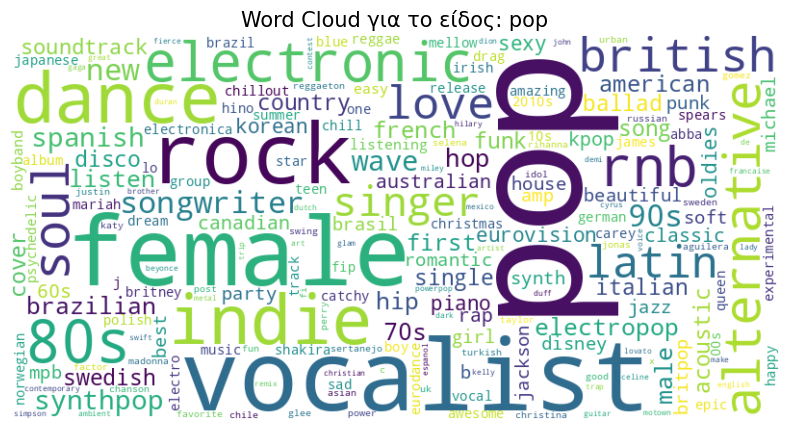

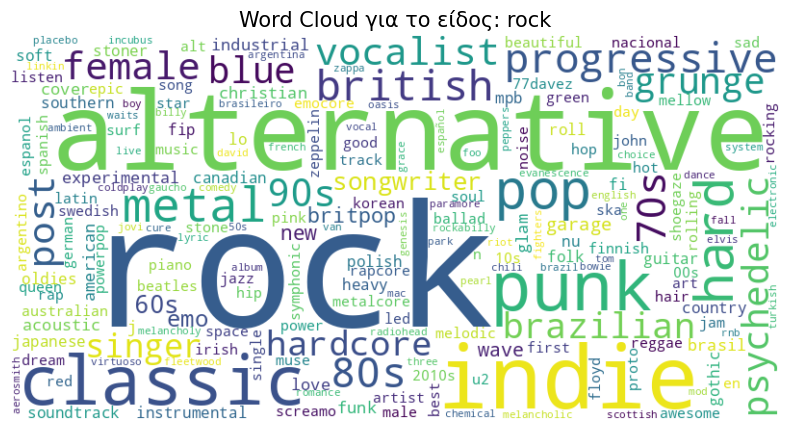

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud


def create_wordcloud(df, genre_name):
    # Φιλτράρουμε το dataframe για το συγκεκριμένο είδος
    # Χρησιμοποιούμε τη στήλη 'top_genres' που φαίνεται πιο καθαρή στην εικόνα
    filtered_df = df[df['top_genres'].str.lower() == genre_name.lower()]
    if filtered_df.empty:
        print(f"Δεν βρέθηκαν δεδομένα για το είδος: {genre_name}")
        return

    # Συγκεντρώνουμε όλα τα tags σε ένα ενιαίο κείμενο
    # Καθαρίζουμε τυχόν κενές τιμές (NaN) και ενώνουμε τα strings
    text = " ".join(tag for tag in filtered_df['tags'].dropna().astype(str))
    
    # Επειδή τα tags είναι χωρισμένα με κόμματα στο dataset σου, 
    # αντικαθιστούμε τα κόμματα με κενά για να τα αναγνωρίσει το WordCloud ως ξεχωριστές λέξεις
    text = text.replace(',', ' ')

    # Δημιουργία του Word Cloud
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        colormap='viridis',
        collocations=False,
        #font_path=font_path_absolute
    ).generate(text)

    # Εμφάνιση του αποτελέσματος
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud για το είδος: {genre_name}", fontsize=15)
    plt.axis("off") 
    plt.show()
    

create_wordcloud(bert_autoencoder_ds, 'pop')
create_wordcloud(bert_autoencoder_ds, 'rock')






### Β.Bar Chart

- Για αυτό το task της άσκησης  έχουμε ένα utility function το οποίο δεχεται ως όρισμα το dataset και το είδος
και φτιάχνει ένα bar char με τα top (10) tags για το συγκεκριμένο είδος γενικά το κάνουμε για τα top-5 genres 

- Παρακάτω αναλύουμε τα πιο ενδιφέροντα συμπεράσματα για καθένα από τα 5 είδη 

#### 1.Pop

- Το tag "female vocalists" είναι το δεύτερο πιο συχνό (6.035 εμφανίσεις). Αυτό μας λέει ότι η  pop  στο dataset  
εκπροσωπείται σε πολύ μεγάλο βαθμό από γυναίκες καλλιτέχνιδες οι οποίες κυριαρχούν στο είδος.  
(όπως η Cheryl ή η Dua Lipa)

- Απο το tag Rock (3.050)  βλέπουμε ότι ένα μεγάλο μέρος των τραγουδιών που έχουν ταξινομηθεί ως "pop" 
έχουν έντονα στοιχεία rock μέσα τους δείχνοντας η αυστηρός διαχωρισμός των τραγουδιών σε είδη ίσως είναι 
πιο δύσκολο πρόβλημα από ότι περιμέναμε. Επίσης βλέπουμε την σύνδεση της pop και με άλλα είδη πχ electronic 

- Το tag Dance (3.018) μας δείχνει ότι ένα μεγάλο μέρος των τραγουδιών της pop είναι χορευτικά κομμάτια. 
Έτσι οι χορογραφίες συνδέονται πιο έντονα με αυτό το είδος από ότι τα υπόλοιπα 

- Η παρουσία των "80s" στα top 10 tags δείχνει ότι το dataset περιλαμβάνει είτε 
κλασικά κομμάτια εκείνης της δεκαετίας, είτε σύγχρονη ποπ που αντλεί έμπνευση από τον ήχο των 80s 
δηλαδη remix κομματια κοκ.

- Το tag "british" υποδηλώνει μια κυριαρχεία των Βρετανών καλλιτεχνών (κυρίως γυναικών) στο είδος. 

#### 2. Rock 

- Εδώ το διάγραμμα μας οδηγεί στο να βγάλουμε περισσότερα συμπεράσματα για τον κατακερματισμο της 
rock στα διάφορα είδη της παρά για το ίδιο το είδος. 

- Τα tags alternative (6.883) και alternative rock (5.700) υποδηλώνουν την κυριαρχεία της alternative 
rock και της σύγχρονης rock στο dataset έναντι της κλασικής rock (3.958) και της hard rock  (2.280)

- Η παρουσία του punk και του british δείχνει μια συγκεκριμένη αισθητική κατεύθυνση, 
πιθανώς με πολλά συγκροτήματα (και καλλιτέχνες) από τη Βρετανία (ξανά!!!!) 

#### 3. Electronic 

- Τα tags ambient (1.530) και experimental (1.404) βρίσκονται πολύ ψηλά. 
Αυτό δείχνει ότι το δείγμα  δεν περιλαμβάνει μόνο "mainstream" electronic μουσική 

- Η παρουσία του synthpop (1.264) και του dance (1.121) τόσο στην pop όσο και στην electronic
επιβεβαιώνει τη έντονη σύνδεση της με την  Pop. Όποτε μάλλον θα έχουμε κάποια δυσκολία στο
classification τους. 

- Γενικά και τα υπόλοιπα tags επιβεβαιώνουν ότι έχουμε πολλούς καλλιτέχνες που  δεν 
κάνουν  mainstream μουσική. 



#### 4. Metal 

-Όπως και η rock αλλά σε μεγαλύτερο βαθμό η Metal έχει πολλά συγκεκριμένα υπο-είδη.
Death Metal, Thrash Metal, Metalcore, Progressive, Gothic κοκ. Άρα ο κατακερματισμός στην 
Metal είναι ακόμα μεγαλύτερος ίσως και για αύτο να έχουμε και λιγότερα κομμάτια ως καθαρή metal στο dataset 

-Το heavy metal (1.807)  κυριαρχεί στο dataset , αλλά αμέσως μετά ακολουθούν οι πιο ακραίοι ήχοι 
(death και thrash ) χωρίς η διαφορά να είναι τεράστια που συμαίνει ότι η metal μάλλον κατακερματίζεται 
ομοιόμορφα στο dataset σε πολλά είδη.

-Τα tags rock (906) και hard rock (884) εμφανίζονται μέσα στα top 10 της Metal μας δείχνουν ότι πολλά τραγούδια βρίσκονται 
στο "μεταίχμιο" – είναι δηλαδή αρκετά σκληρά για να θεωρηθούν Metal, αλλά διατηρούν τη δομή της Rock.


#### 5. Folk 

- Εδώ παρατηρούμε οτι η folk συνδέεται τόσο με την rock όσο και με την pop. 

- Τα tags singer-songwriter (2.153) και το acoustic (1.244) δείχνουν ότι η πλειοψηφία των κομματιών βασίζεται 
στη φωνή και την κιθάρα/πιάνο όπως η pop 

- Με 797 εμφανίσεις, οι γυναικείες φωνές παίζουν ξανά καθοριστικό ρόλο (όπως και στην Pop), 
Άρα ίσως παρατηρούμε ότι οι γυναίκες καλλιτέχνες έχουν μια τάση ως προς  τα πιο φωνητικά είδη όπως η pop και η folk 

- Tο tag indie (2.568) είναι εξαιρετικά ισχυρό. 
Η σύγχρονη Folk είναι πλέον σχεδόν ταυτόσημη με την "Indie Folk" σκηνή (πράγμα που συμβαίνει και στο rock).





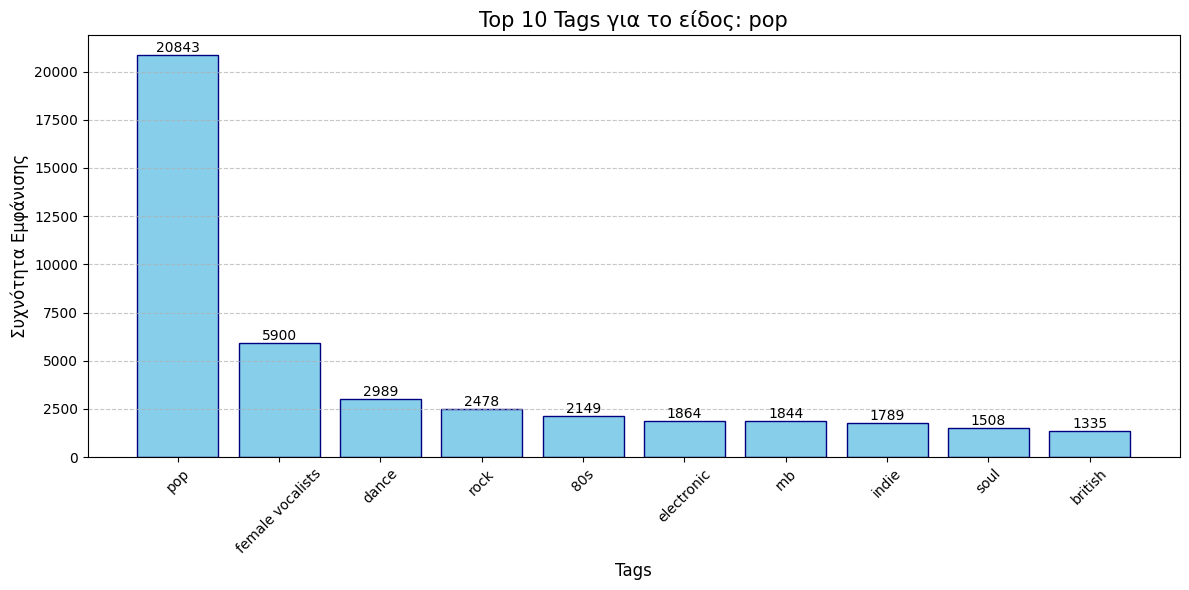

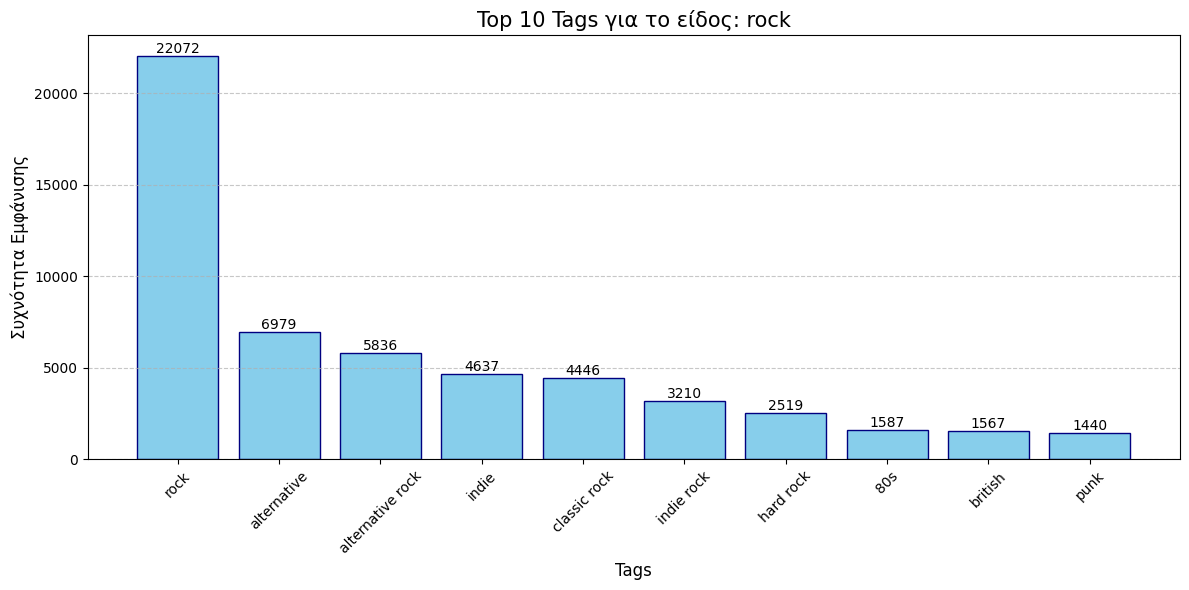

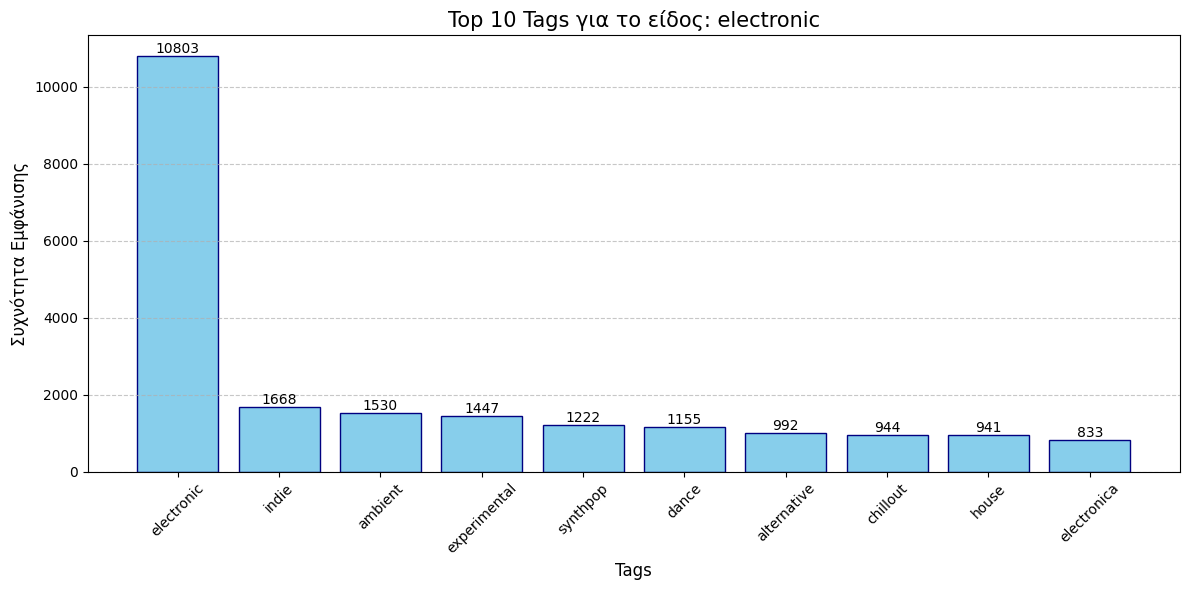

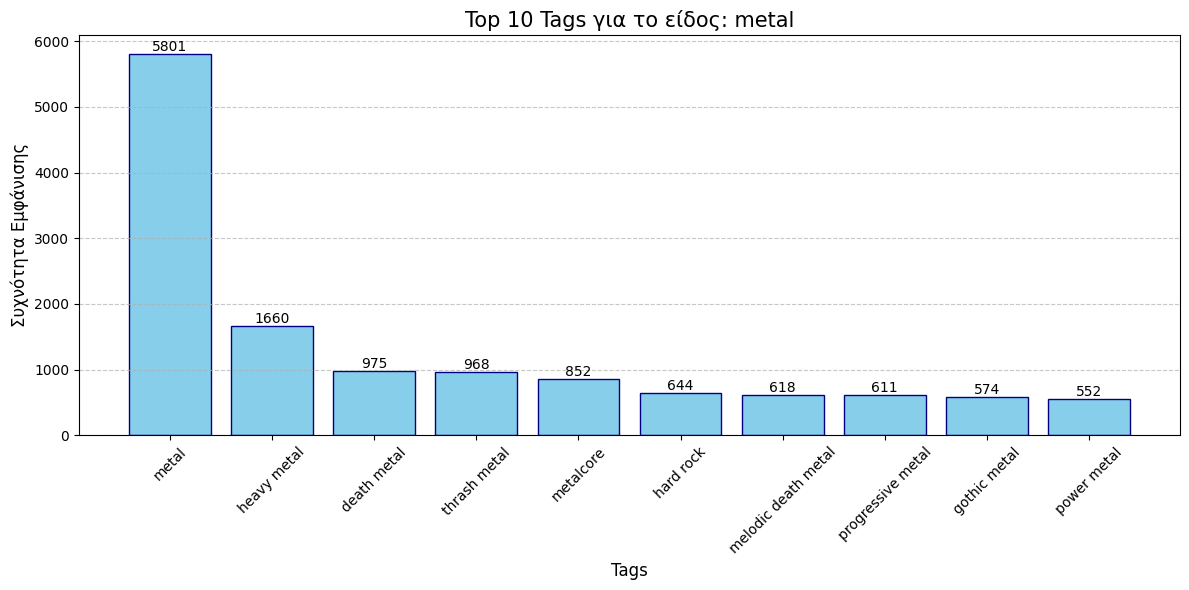

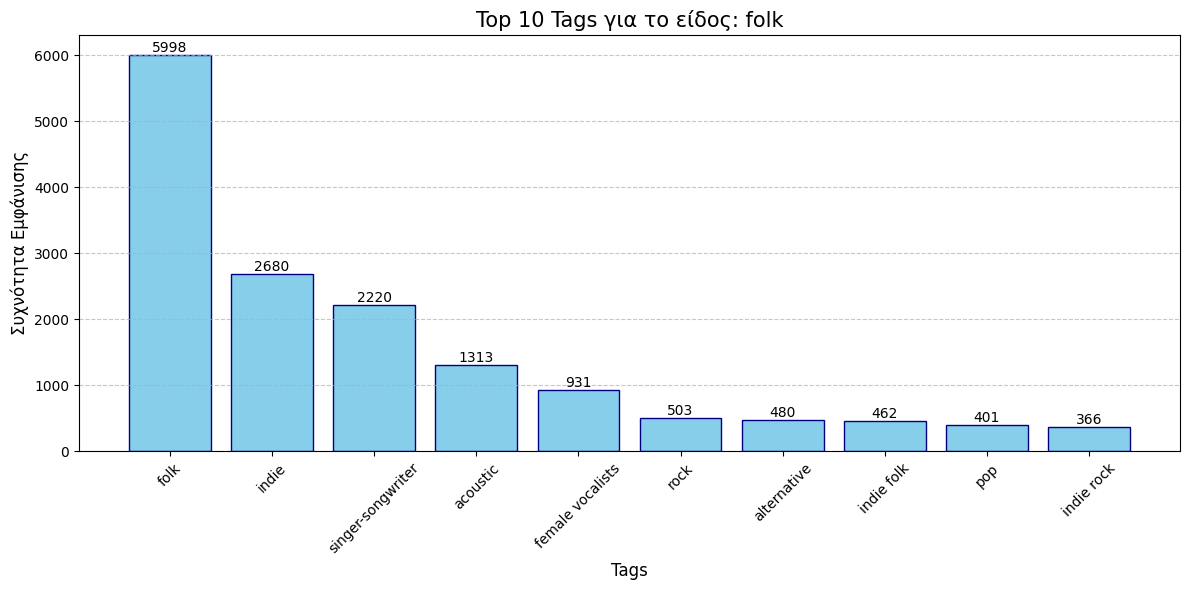

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def plot_top_tags_by_genre(df, genre_name, top_n=10):
    # Φιλτράρισμα βάσει είδους
    filtered_df = df[df['top_genres'].str.lower() == genre_name.lower()]
    
    if filtered_df.empty:
        print(f"Δεν βρέθηκαν δεδομένα για το είδος: {genre_name}")
        return

    # Συλλογή όλων των tags σε μια λίστα
    all_tags = []
    for tags_row in filtered_df['tags'].dropna().astype(str):
        # Χωρίζουμε τα tags με βάση το κόμμα και αφαιρούμε τα κενά γύρω τους
        tags_list = [tag.strip().lower() for tag in tags_row.split(',')]
        all_tags.extend(tags_list)

    # Καταμέτρηση συχνότητας
    tag_counts = Counter(all_tags)
    
    # Παίρνουμε τα top_n πιο συχνά (π.χ. τα 10 πρώτα)
    most_common = tag_counts.most_common(top_n)
    
    # Διαχωρισμός σε labels (ονόματα) και values (συχνότητες) για το chart
    tags, counts = zip(*most_common)

    # 4. Δημιουργία του Bar Chart
    plt.figure(figsize=(12, 6))
    bars = plt.bar(tags, counts, color='skyblue', edgecolor='navy')
    
    # Προσθήκη των αριθμών πάνω από κάθε μπάρα για σαφήνεια
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

    plt.title(f"Top {top_n} Tags για το είδος: {genre_name}", fontsize=15)
    plt.xlabel("Tags", fontsize=12)
    plt.ylabel("Συχνότητα Εμφάνισης", fontsize=12)
    plt.xticks(rotation=45) # Κλίση στα ονόματα για να μη συμπίπτουν
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
# Εφόσον έχουμε το utility function στα χέρια μας μπορούμε να 
# έχουμε το bar char για κάθε είδος 

top_genres = ['pop', 'rock', 'electronic', 'metal', 'folk']

for g in top_genres:     
    plot_top_tags_by_genre(bert_autoencoder_ds, g)



### Γ1. Χρήση PCA για την μείωση των διαστάσεων σε 2D

- Αρχικά επιλέγουμε ένα δείγμα 10.000 τραγουδιών καθώς 60.000 τραγούδια είναι πάρα πολλά για οπτικοποίηση

- Χρησιμοποιούμε ένα utility function το οποίο επιστρέφει ένα pandas dataframe το οποίο έχει τις 
δυο ζητούμενες διαστάσεις των τραγουδιών χρησιμοποιώντας pca με γραμμικό τρόπο όπως είδαμε πιο πάνω. 

-Στην συνέχεια φτιάχνουμε ένα plot τοποθετώντας τα στο επίπεδο και καταγράφουμε τις παρατηρήσεις μας.  

#### 1. Γράφημα Lyrics (BERT Embeddings)

- Εδώ ως προς τους στοίχους βλέπουμε μια τάση διαχωρισμού της pop από τα υπόλοιπα είδη μουσικής 
- Τα pop τραγούδια φαίνεται να καταλαμβάνουν το πιο πυκνό, νοτιο κεντρικό κομμάτι του νέφους ενώ 
- Ενώ η rock/electronic και τα υπόλοιπα τραγούδια φαίνεται να να πιάνουν το βορειο κεντρικο κομμάτι 
του νέφους καθώς η pop έχει πιο standard στοίχους από τα υπόλοιπα είδη. 
- Ομως ο  διαχωρισμός αυτός είναι ελαφρύς χωρίς να μπορούμε να ξεχωρίσουμε κάποιον σχηματισμός ξεχωριστών συστάδων 
ανά μουσικό είδος. Είναι ένα γιγάντιο cluster.
- Ενδιαφέρον έχει ένα outlier τραγούδι ως προς τους στοίχους δεξιά το οποίο φαίνεται να ξεχωρίζει πολύ από τα υπόλοιπα

#### 2. Γράφημα Audio Features (AE)
- Εδώ φαίνεται ένα σχήμα βεντάλιας το οποίο ανοίγει προς τα δεξιά 

- Γύρω από την περιοχή ae_pca_1 = 0 φαίνεται  μια πυκνή μάζα όπου συγχέονται όλα τα είδη (Pop, Folk, Rock)
Αυτό πιθανότατα αντιπροσωπεύει τη βασική δομή ενός τυπικού τραγουδιού όπου τα είδη ακούγονται ακουστικά όμοια στο μοντέλο 

- Καθώς κινούμαστε προς τα δεξιά και πάνω, βλέπουμε τα electronic και τα pop σημεία να απλώνονται σε τεράστιο εύρος. 
Αυτό ίσως να γίνεται γιατι  η ηλεκτρονική και η pop μουσική έχουν τεράστια ποικιλία στους συνθετικούς ήχους τα εφέ και τα beats
δημιουργώντας μεγάλo variance στα audio features ειδικά τα remix.

- Folk: Παρατηρούμε ότι τα folk σημεία δεν απλώνονται πολύ. 
Είναι συγκεντρωμένα στην περιοχή γύρω από το σημείο ae_pca_2 = -3. Αυτό δείχνει ότι ακουστικά, τα folk τραγούδια 
(συνήθως φωνή, κιθάρα, ακουστικά όργανα) έχουν πολύ μικρότερη variance ακουστικα από την Electronic.

- Rock/Metal: Έχουν  μια χαλαρή τάση να απλώνονται  προς το νότιο μέρος της βεντάλιας για τους λόγους που εξηγήσαμε 
ξεχωρίζουντας ακουστικά από τα pop/electronic κομμάτια


#### Γενικό Συμπέρασμα
- Ο ήχος είναι αυτός που χαρακτηρίζει το μουσικό είδος (Genre) πολύ περισσότερο από τους  στίχους. 
Όμως όπως είδαμε σε προηγούμε cell ο PCA είναι ένας γραμμικός αλγόριθμος.Στην συνέχεια τρέχουμε 
τον αλγόριθμο t-sne που είναι μη γραμμικός.  

- Τα συμπεράσματα αυτά ισχύουν για σχεδόν όλα τα δείγματα που τρέξαμε καθώς στην αρχή επιλέγουμε 
τυχαία κάποιο δείγμα από το dataset.


In [13]:
# Αν δεν έχουμε το seaborn το κάνουμε install  
# %pip install seaborn

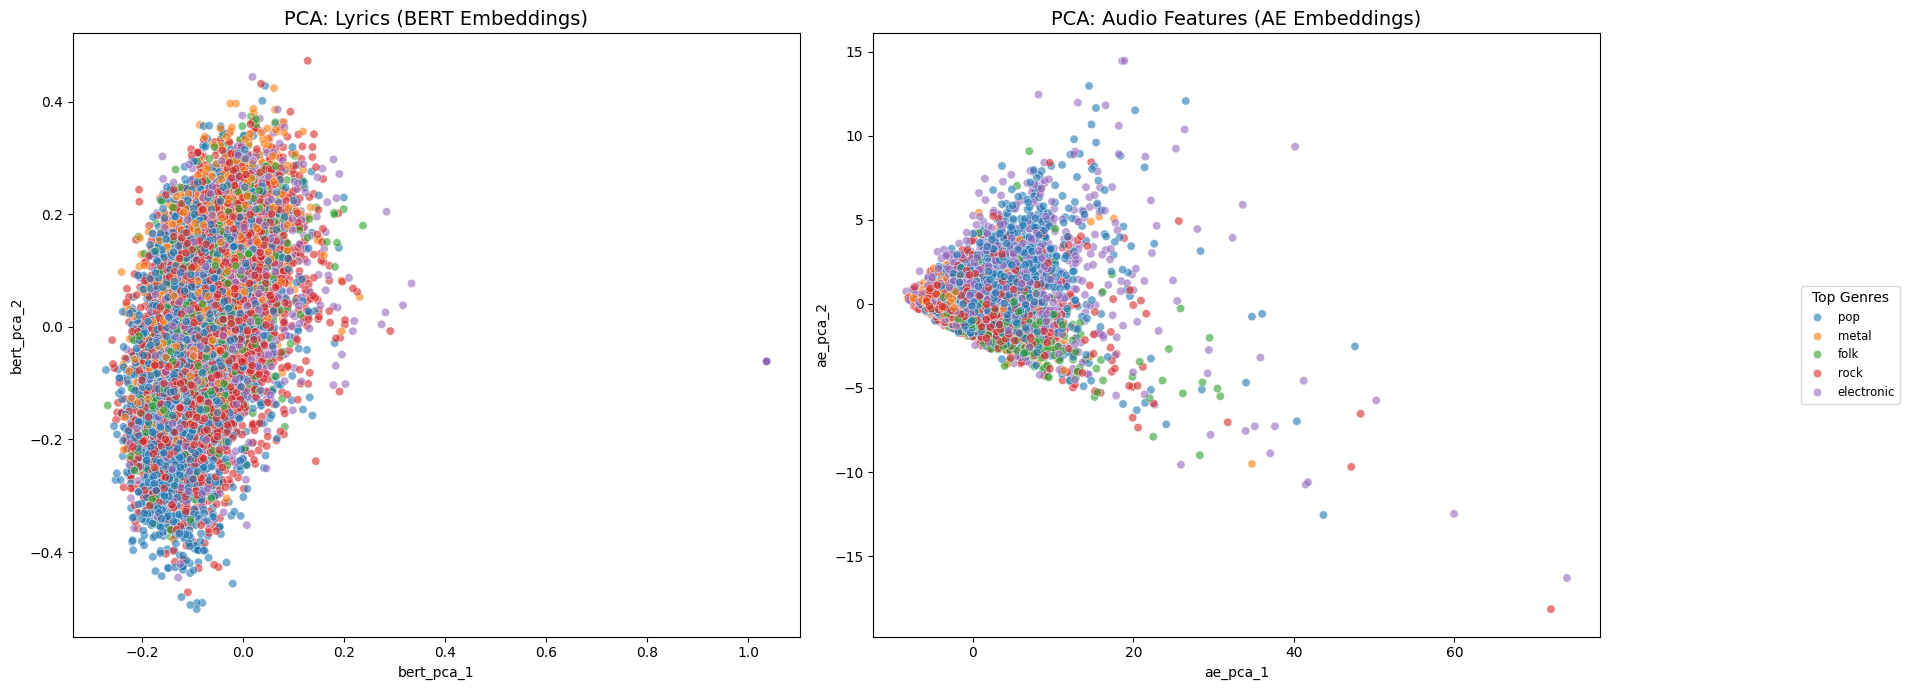

In [11]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns



"""Εδώ έχουμε ένα function το οποίο παίρνει embeddings από το dataset αρχικοποιεί τα pca  
για τις δυο διαστάσεις και στην συνέχεια τα εφαρμόζει στα δεδομένα. Τέλος επιστρέφει ένα pandas dataframe   
για την εύκολη διαχείρισή τους"""
def apply_pca_transform(df): 
    bert_cols = [col for col in df.columns if col.startswith('bert_feature_')]
    ae_cols = [col for col in df.columns if col.startswith('AE_emb_')]
    pca_bert = PCA(n_components=2)
    pca_ae = PCA(n_components=2)
    
    df_transformed = df.dropna(subset=bert_cols + ae_cols).copy()
    
    bert_pca_result = pca_bert.fit_transform(df_transformed[bert_cols])
    ae_pca_result = pca_ae.fit_transform(df_transformed[ae_cols])    
    
    df_transformed['bert_pca_1'] = bert_pca_result[:, 0]
    df_transformed['bert_pca_2'] = bert_pca_result[:, 1]

    df_transformed['ae_pca_1'] = ae_pca_result[:, 0]
    df_transformed['ae_pca_2'] = ae_pca_result[:, 1]
    
    return df_transformed


"""Εδώ έχουμε ένα function το οποίο εφαρμόζει τα Scatter plots για τα  audio 
και τα lyric embeddings ξεχωριστά δίπλα δίπλα """
def apply_pca_plots(df): 
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot 1: Lyrics (BERT Embeddings)
    sns.scatterplot(
        x='bert_pca_1', y='bert_pca_2',
        hue='top_genres',
        data=df,
        ax=axes[0],
        alpha=0.6,
        palette='tab10',
        legend=False # Απενεργοποιούμε το legend εδώ
    )
    axes[0].set_title('PCA: Lyrics (BERT Embeddings)', fontsize=14)

    # Plot 2: Audio (Autoencoder Embeddings)
    sns.scatterplot(
        x='ae_pca_1', y='ae_pca_2',
        hue='top_genres',
        data=df,
        ax=axes[1],
        alpha=0.6,
        palette='tab10',
        legend=True # Θα πάρουμε το legend από εδώ
    )
    axes[1].set_title('PCA: Audio Features (AE Embeddings)', fontsize=14)

    # Ρύθμιση της απόστασης μεταξύ των δύο γραφημάτων
    plt.subplots_adjust(wspace=0.3)

    # Μετακίνηση του Legend έξω από τα γραφήματα (δεξιά ή κάτω)
    # Εδώ το βάζουμε τέρμα δεξιά για να μην κρύβει τίποτα
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].get_legend().remove() # Αφαιρούμε το αρχικό legend

    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), 
            title="Top Genres", fontsize='small', ncol=1)

    plt.tight_layout(rect=[0, 0, 0.9, 1]) # Αφήνουμε χώρο δεξιά για το legend
    plt.show()
    
    
    
    

sample_ds = bert_autoencoder_ds.sample(10000)
pca_ds = apply_pca_transform(sample_ds)
apply_pca_plots(pca_ds)



### Γ2.Χρήση t-SNE για την μείωση των διαστάσεων σε 2D

- Εδώ έχουμε έναν μη γραμμικό αλγόριθμο τον t-SNE για την μείωση των διαστάσεων σε 2D
οπότε είναι λογικό να έχουμε καλύτερα αποτελέσματα σε σχέση με τον pca 

#### Γράφημα Lyrics (BERT) 

- Εδώ η κατάσταση είναι λίγο καλύτερη σε σχέση με το προηγούμενο γράφημα των lyrics με την χρήση pca 
καθώς φαίνεται ο ελαφρύς σχηματισμός κάποιων συστάδων 

- Τα metal τραγούδια έχουν διαφοροποιηθεί με βάση τα lyrics από τα υπόλοιπα καθώς έχουν σχηματίσει δύο μικρές  συστάδες 
Αυτό μας δείχνει ότι η Metal χρησιμοποιεί ένα πολύ διαφορετικό  σκοτεινό λεξιλόγιο το οποίο την διαφοροποιεί.

- Ανάλογα με το sample βλέπουμε και κάποιες τοπικές νησίδες που διαφοροποιούνται ελαφρά αλλά τα lyrics παραμένουν 
από μόνοι τους, είναι ένα αδύναμο modality για τον διαχωρισμό των τραγουδιών 

- Επίσης ανάλογα με το sample πάλι βλέπουμε την ύπαρξη outliers 


#### Γράφημα Audio Features (AE)

##### Rock/Metal: 
- Στην αριστερή πλευρά βλέπουμε ότι συγκεντρώνονται rock και metal τραγούδι.  
Βλέπουμε μάλιστα ότι η Metal τείνει να δημιουργεί ένα αρκετά πυκνό και διακριτό cluster στην άκρη αριστερά 
με την Rock να λειτουργεί ως το μεταβατικό στάδιο της metal προς το κέντρο.

- Αυτό είναι λογικό καθώς και τα δυο είδη αποτελούνται συνήθως από σκληρό ήχο και διαθέτουν παρόμοια μουσικά όργανα 
όπως ηλεκτρική κιθάρα, ηλεκτρικό μπάσο και Ντραμς (Drums)

- Επίσης είναι κάτι που περιμέναμε λόγω της συσχέτισής τους στα προηγούμενα γραφήματα 


##### Pop/Electronic:

-Στην πάνω δεξιά πλευρά κυριαρχούν τα pop και τα electronic κομμάτια.
- Υπάρχει μεγάλη επικάλυψη μεταξύ τους πράγμα λογικό γιατί και τα δυο 
είδη χρησιμοποιούν  την ηλεκτρονική τεχνολογία ως βασικό εργαλείο παραγωγής ηχου πχ 

1. Synthesizers 
2. Drum Machines 
3. Ηλεκτρονικά Drops
4. Επεξεργασία Φωνής(Autotune)

- Επίσης είναι κάτι που περιμέναμε λόγω της συσχέτισής τους στα προηγούμενα γραφήματα 


##### Folk
- Βρίσκεται διάσπαρτη κυρίως στο κάτω μέρος και κεντρικά. 
Φαίνεται να συγγενεύει περισσότερο με την πιο ακουστική πλευρά της Pop και με κάποια  Rock τραγούδια  
μένοντας μακριά τόσο από την  Metal όσο και από την Electronic.

- H Folk διαφοροποιείται ηχιτικά από αυτά τα είδη καθώς τα κυρίαρχα όργανα 
της είναι η ακουστική κιθάρα, το μπάντζο, το βιολί, το μαντολίνο, η φυσαρμόνικα και το κοντραμπάσο.


#### Γενικά Συμπεράσματα 
- Τόσο στο pca όσο και στο t-sne το modality το οποίο κάνει την διαφορά είναι ο ήχος. 
- Τα ΑΕ Audio Embeddings έχουν καταφέρει να μάθουν την εννοιολογική διαφορά στο ήχο ξεχωρίζοντας τα είδη 
αρκετά καλά για τους λόγους που εξηγήσαμε σε αυτό και σε προηγούμενες παραγράφους. 

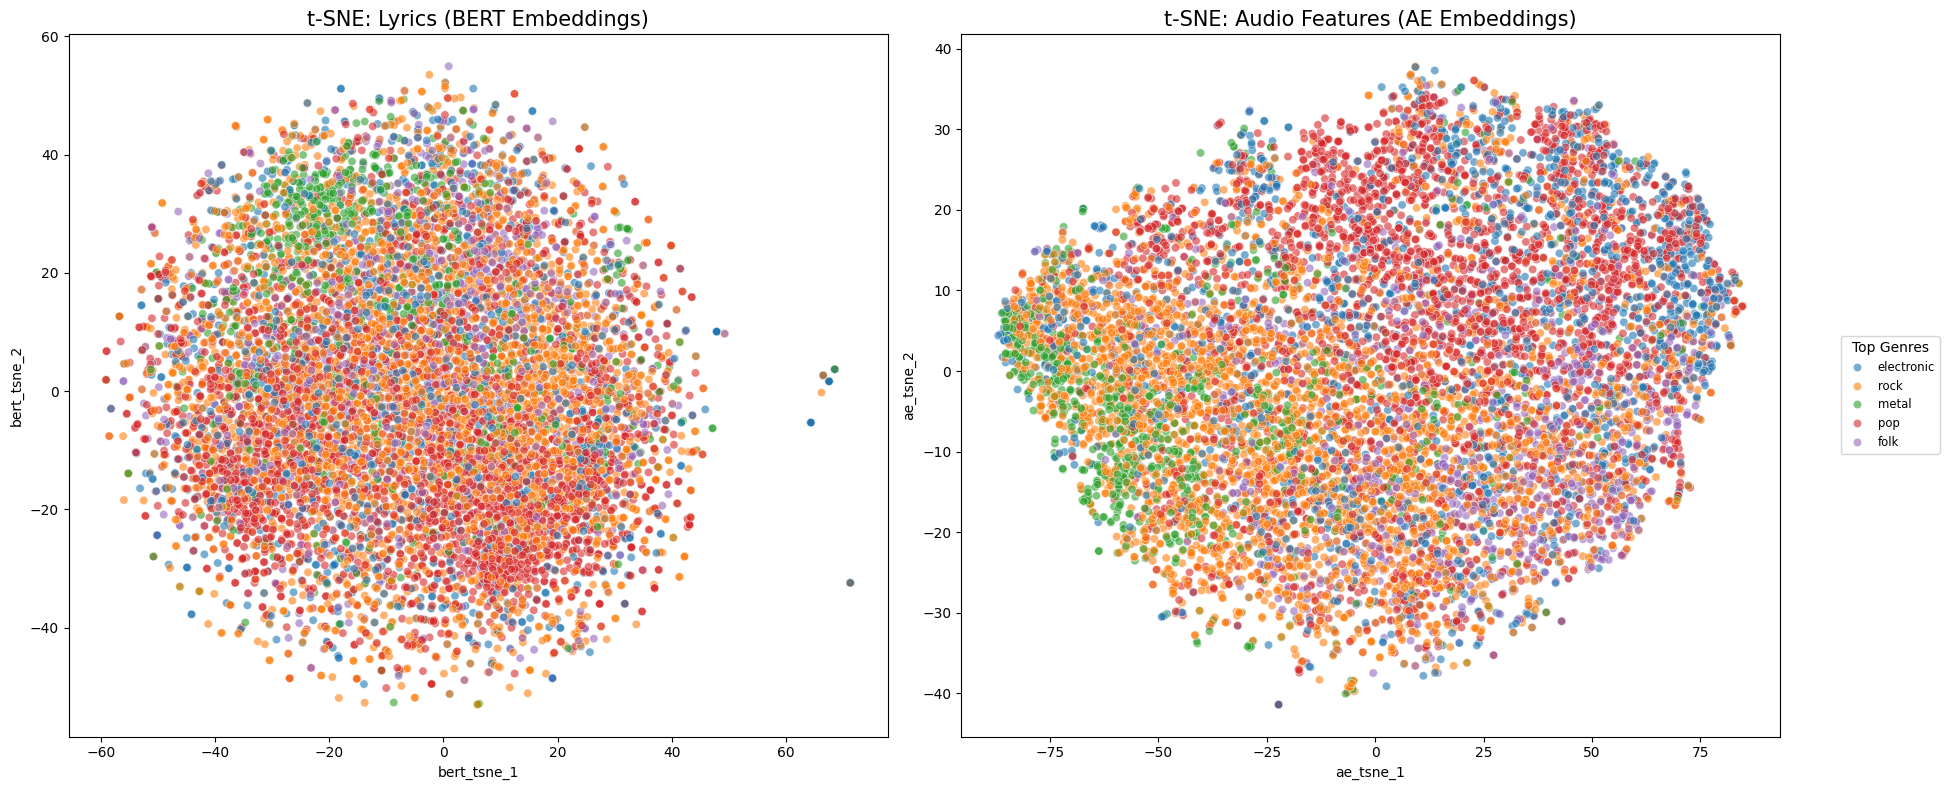

In [12]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns






"""Εδώ έχουμε ένα function το οποίο παίρνει embeddings από το dataset εφαρμόζει  t-sne
για  δυο διαστάσεις. Τέλος επιστρέφει ένα pandas dataframe για την εύκολη διαχείρισή τους"""
def apply_t_sne_transform(df): 
    bert_cols = [col for col in df.columns if col.startswith('bert_feature_')]
    ae_cols = [col for col in df.columns if col.startswith('AE_emb_')]

    # Καθαρισμός NaN
    df_transformed = df.dropna(subset=bert_cols + ae_cols).copy()

    #  Εφαρμογή t-SNE για τα Lyrics
    tsne_bert = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    bert_tsne_result = tsne_bert.fit_transform(df_transformed[bert_cols])

    # Εφαρμογή t-SNE για τα Audio
    tsne_ae = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    ae_tsne_result = tsne_ae.fit_transform(df_transformed[ae_cols])

    # Αποθήκευση αποτελεσμάτων
    df_transformed['bert_tsne_1'] = bert_tsne_result[:, 0]
    df_transformed['bert_tsne_2'] = bert_tsne_result[:, 1]
    df_transformed['ae_tsne_1'] = ae_tsne_result[:, 0]
    df_transformed['ae_tsne_2'] = ae_tsne_result[:, 1]
    
    return df_transformed


def apply_t_sne_plots(df):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot 1: Lyrics (t-SNE)
    sns.scatterplot(
        x='bert_tsne_1', y='bert_tsne_2',
        hue='top_genres',
        data=df,
        ax=axes[0],
        alpha=0.6,
        palette='tab10',
        legend=False
    )
    axes[0].set_title('t-SNE: Lyrics (BERT Embeddings)', fontsize=15)

    # Plot 2: Audio (t-SNE)
    sns.scatterplot(
        x='ae_tsne_1', y='ae_tsne_2',
        hue='top_genres',
        data=df,
        ax=axes[1],
        alpha=0.6,
        palette='tab10',
        legend=True
    )
    axes[1].set_title('t-SNE: Audio Features (AE Embeddings)', fontsize=15)

    # Διόρθωση απόστασης και Legend
    plt.subplots_adjust(wspace=0.25)
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].get_legend().remove()

    # Τοποθέτηση του legend στα δεξιά
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.92, 0.5), 
            title="Top Genres", fontsize='small', ncol=1)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


sample_ds = bert_autoencoder_ds.sample(10000)
t_sne_ds = apply_t_sne_transform(sample_ds)
apply_t_sne_plots(t_sne_ds)



### Γ3. Κατανομή Τραγουδιών με βάση τον αριθμό των genres τους. 

- Για να οπτικοποιήσουμε την κατανομή των τραγουδιών με βάση το πλήθος των ειδών (genres) 
στα οποία ανήκουν, το καταλληλότερο διάγραμμα είναι ένα Bar Chart.

- Το βασικό συμπέρασμα που προκύπτει από αυτή την κατανομή είναι ότι 
η μουσική στο data set είναι "υβριδική" ως προς το είδος  δηλαδη η πλειοψηφία των τραγουδιών που έχουμε  
δεν ανήκουν σε ένα  "καθαρό" είδος (π.χ. μόνο Rock). 

- Αντίθετα  είναι ένας συνδυασμός πολλών ειδών(π.χ. Rock και Indie ή Pop και Dance).

- Η κορυφή της κατανομής βρίσκεται στα 2 είδη (21.794 τραγούδια) ενώ ενα συντριπτικό μέρος 
του dataset έχει τραγούδια που ανήκουν σε 2 ή 3 είδη. 

- Μετά τα 4 είδη, ο αριθμός των τραγουδιών πέφτει κατακόρυφα που συμαίνει 
ότι υπάρχει ένα λογικό όριο στην περιγραφή ενός τραγουδιού ως προς το είδος.

- Γενικά μπορούμε να δούμε ότι κανονικά η επιλογή του ως προς είδος 
πρόκειται για ένα multilabel classification πρόβλημα. 









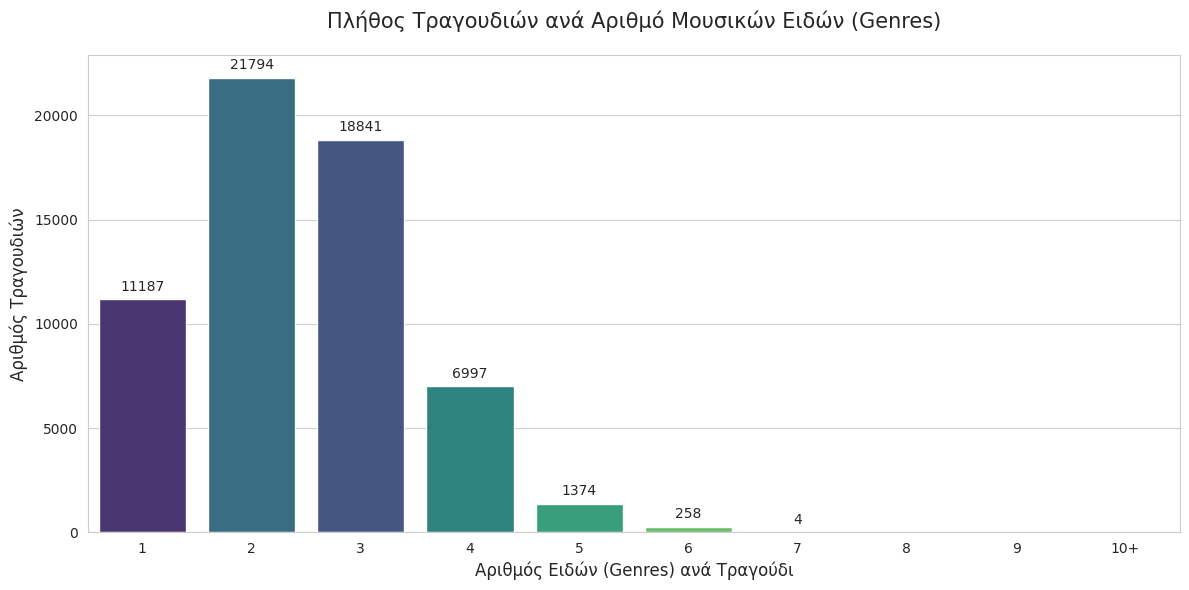

In [13]:

"""Utility function το οποίο δέχεται το dataset και κάνει plot την κατανομή των τραγουδιών με βάση το πλήθος genres. """
def songcount_per_genrecount_chart(df): 
    df['genre_count'] = df['genres'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

    # Αν υπάρχουν τραγούδια με πάρα πολλά genres, τα βάζουμε σε μια κατηγορία '10+'
    df['genre_count_grouped'] = df['genre_count'].apply(lambda x: '10+' if x >= 10 else str(x))

    # Ταξινόμηση των κατηγοριών για το γράφημα
    order = [str(i) for i in range(1, 10)] + ['10+']

    # Δημιουργία του γραφήματος
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    ax = sns.countplot(
        data=df, 
        x='genre_count_grouped', 
        order=order, 
        palette='viridis', 
        hue='genre_count_grouped',  
        legend=False    
    )            

    plt.title('Πλήθος Τραγουδιών ανά Αριθμό Μουσικών Ειδών (Genres)', fontsize=15, pad=20)
    plt.xlabel('Αριθμός Ειδών (Genres) ανά Τραγούδι', fontsize=12)
    plt.ylabel('Αριθμός Τραγουδιών', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', 
                    va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

    plt.tight_layout()
    plt.show()

    
songcount_per_genrecount_chart(bert_autoencoder_ds)    
    


### Γ4. Κατανομή των top 10 genre με βάση το πλήθος των τραγουδιών  

- Εδώ απαντάμε στο ακριβώς επόμενο ερώτημα όπου εφαρμόζουμε την ακριβώς αντίστροφη διαδικασία δηλαδή
 πρώτα να βρίσκουμε τα top genres και έπειτα κάνουμε plot την κατανομή των τραγουδιών στα κορυφαία είδη.

#### Γενικές  Παρατηρήσεις
- Εδώ βλέπουμε την απόλυτη κυριαρχία της rock η οποία φαίνεται να έχει το μεγαλύτερο support στο dataset όχι μόνο 
επειδή είναι πρώτη (23.946 τραγουδια) αλλα επειδή το 50% των top-5 ειδών είναι rock ή υποείδος της rock.
Rock, Alternative Rock, Classic Rock, Ιndie Rock, Hard Rock 

- Υπάρχει μια τεράστια διαφορά ανάμεσα στις τρεις πρώτες κατηγορίες (rock, pop, electronic)
Άρα οι κύριες κατηγορίες είναι τρεις και κυρίως rock και pop.

- Από τα δύο προηγούμενα γραφήματα γίνεται πιο προφανές ότι υπάρχει μεγάλη επικάλυψη στο dataset 
πχ πολλά από τα 2.920 τραγούδια της Hard Rock περιλαμβάνονται επίσης και στα 23.949 
της γενικής κατηγορίας Rock κοκ αυτό είναι κάτι που το περιμέναμε.

- Γενικά έχουμε ένα έντονο imbalance στα δεδομένα μας 
πχ παρατηρούμε οτι η Rock έχει  σχεδόν 8 φορές μεγαλύτερο suppport από την Hard Rock.
Αυτό μπορεί να είναι καταστροφικό για έναν αλγόριθμο μηχανικής μάθησης καθώς λόγω αυτής της διαφοράς 
στο support μπορεί να γίνει "τεμπέλικο" και να προβλέπει παντού κατηγορίες με το μεγαλύτερο support 
πχ Rock 

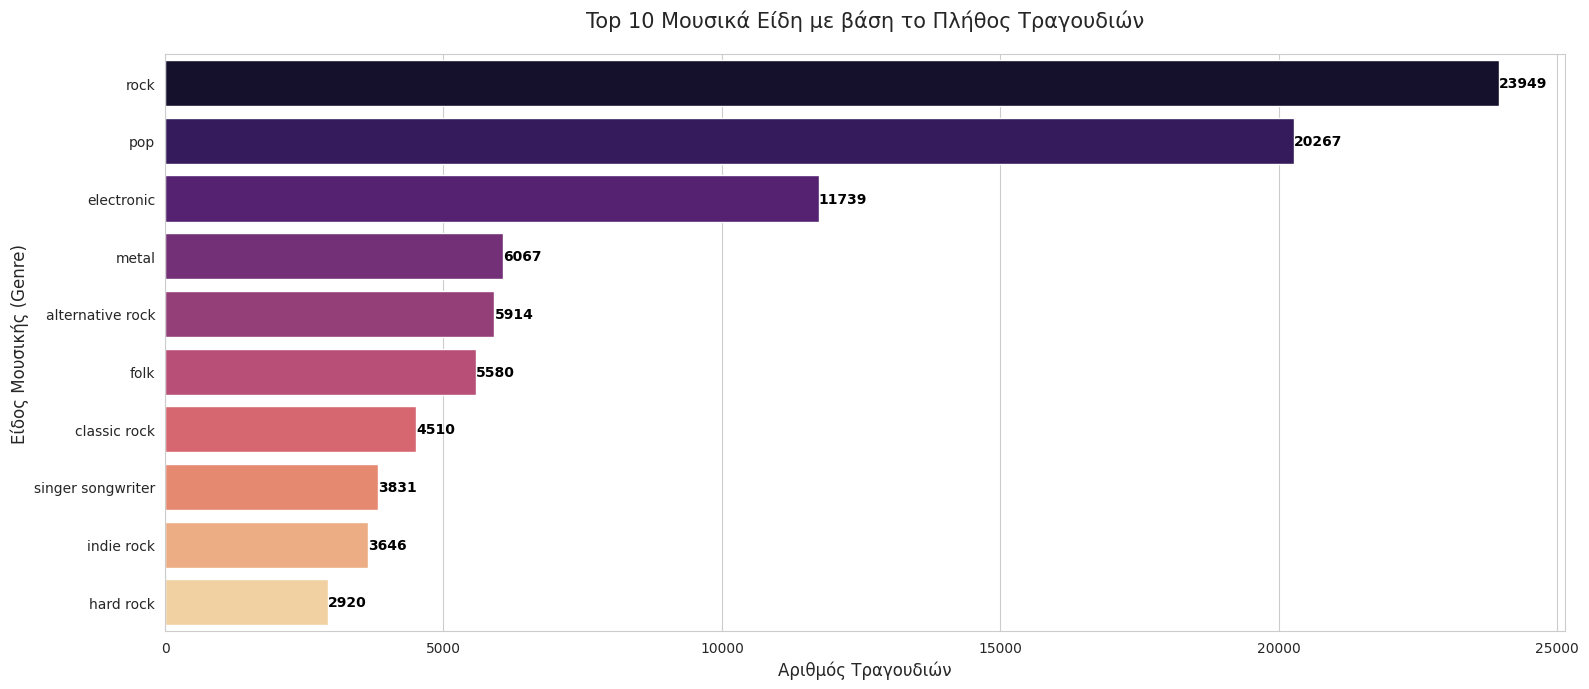

In [14]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



def songcount_per_topgenre_chart(df, top_n): 
        
    # Υπολογισμός των συχνοτήτων και επιλογή των top_n
    genres_series = df['genres'].dropna().str.split(',').explode().str.strip()
    top_genres_counts = genres_series.value_counts().head(top_n)

    # Μετατροπή σε DataFrame για ευκολότερη σχεδίαση
    top_genres_df = top_genres_counts.reset_index()
    top_genres_df.columns = ['Genre', 'Count']

    plt.figure(figsize=(16, 7))
    sns.set_style("whitegrid")

    ax = sns.barplot(
        data=top_genres_df, 
        y='Genre', 
        x='Count', 
        palette='magma',
        hue='Genre',   
        legend=False
    )

    plt.title(f'Top {top_n} Μουσικά Είδη με βάση το Πλήθος Τραγουδιών', fontsize=15, pad=20)
    plt.xlabel('Αριθμός Τραγουδιών', fontsize=12)
    plt.ylabel('Είδος Μουσικής (Genre)', fontsize=12)

    # Προσθήκη των τιμών στο τέλος κάθε μπάρας
    for i, v in enumerate(top_genres_df['Count']):
        ax.text(v + 3, i, str(int(v)), color='black', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
    


songcount_per_topgenre_chart(bert_autoencoder_ds, 10)






### Γ5. Κατανομή των lyrics στα τραγούδια 
- Σε αυτό το cell για το επόμενο ερώτημα αναδεκνύουμαι την κατανομή των lyrics και στην 
συνέχεια απαντάμε στα ερωτήματα τις άσκησης σχετικά με την κατανομή των χαρακτήρων και των 
λέξεων. 

#### Κανομή χαρακτήρων 
- Η κορυφή βρίσκεται πλέον με ακρίβεια μεταξύ 500 και 600 χαρακτήρων.

- Η συντριπτική πλειοψηφία των τραγουδιών σου (το "σώμα" της κατανομής) βρίσκεται 
ανάμεσα στους 300 και 900 χαρακτήρες. Πιθανό να  πρόκειται και από τα προηγούμενα 
γραφήματα για τα standard κομμάτια του dataset pop rock κοκ 

- Μετά τους 1.000 χαρακτήρες, η καμπύλη πέφτει ομαλά. 
Αυτό μας λέει ότι όσο αυξάνεται το κείμενο, τόσο πιο σπάνιο γίνεται το τραγούδι.
Αυτά είναι πιθανότατα κομμάτια Rap,Hip-Hop,Metal κομμάτια. 

- Αντίθετα βλέπουμε ότι υπάρχουν και τραγούδια χωρίς στοίχους και μετά 
το μηδέν η καμπύλη πέφτει απότομα. Αυτό πιθανότατα ωφείλετε στην ύπαρξη της 
electronic μουσικής. 

### Κατανομή λέξεων 

- Η καμπύλη των "Meaningful" λέξεων (πράσινη) είναι αρκετά κοντά σε εκείνη των συνολικών λέξεων (πορτοκαλί), 
με την κορυφή να εντοπίζεται γύρω στις 100 λέξεις ανά τραγούδι.

- Το γεγονός ότι οι δύο καμπύλες ταυτίζονται σε μεγάλο βαθμό στο σχήμα τους δείχνει ότι, 
παρά την αφαίρεση των stopwords  η δομή του τραγουδιού παραμένει σταθερή.

- Αυτό είναι λογικό καθώς το πρόβλημα έχει να κάνει με μουσικούς στοίχους πράγμα που σημαίνει ότι
αυτοί πρέπει να έχουν κάποια μελωδία εκτός και αν έχει γίνει νωρίτερα κάποια επεξεργασία. 


In [18]:
#Κατεβάζουμε την nltk library για στα stopwords αν δεν υπάρχει 
# %pip install nltk

[nltk_data] Downloading package stopwords to /home/apg13/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


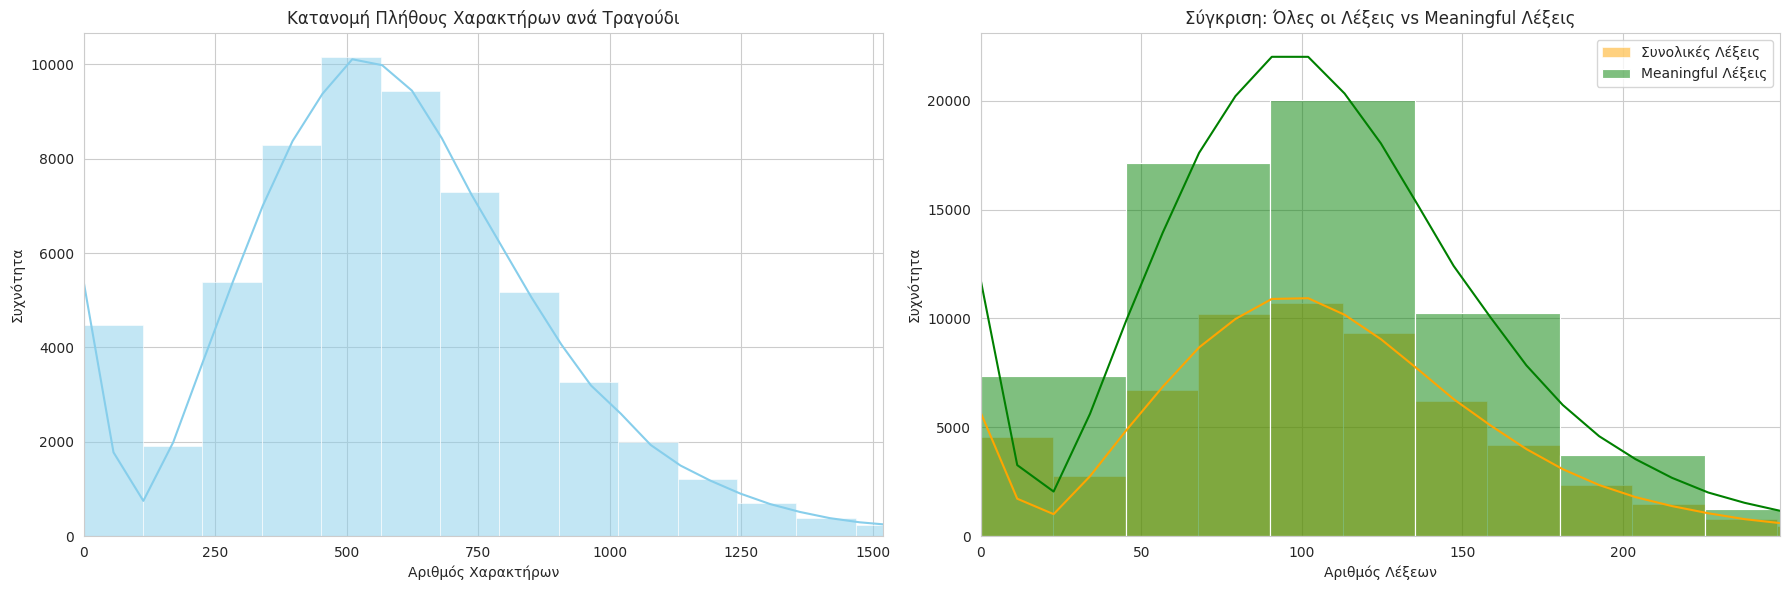

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
from nltk.corpus import stopwords


def plot_lyrics_distribution(df):
    nltk.download('stopwords')           # downloading the stopwords
    stop_words = set(stopwords.words('english')) 
    def get_meaningful_count(text, stop_words):
        words = str(text).lower().split()
        meaningful_words = [w for w in words if w not in stop_words and w.isalpha()]
        return len(meaningful_words)
    
    # δημιουργία νεων attribute με τον  υπολογισμό χαρακτήρων και λέξεων 
    df['char_count'] = df['lyrics'].astype(str).apply(len)
    df['word_count'] = df['lyrics'].astype(str).apply(lambda x: len(x.split()))
    df['meaningful_wc'] = df['lyrics'].apply(get_meaningful_count, stop_words=stop_words)
  
        
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Γράφημα 1: Κατανομή Χαρακτήρων
    upper_limit = df['char_count'].quantile(0.99) # Βρίσκουμε το όριο του 99% των δεδομένων
    sns.histplot(df['char_count'], bins=100, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title('Κατανομή Πλήθους Χαρακτήρων ανά Τραγούδι')
    axes[0].set_xlabel('Αριθμός Χαρακτήρων')
    axes[0].set_ylabel('Συχνότητα')
    axes[0].set_xlim(0, upper_limit) 
    axes[0].set_xticks(np.arange(0, upper_limit + 1, 250))
    
    
    

    # Γράφημα 2: Σύγκριση Λέξεων (Total vs Meaningful)
    sns.histplot(df['word_count'], bins=100, kde=True, color='orange', label='Συνολικές Λέξεις', ax=axes[1], alpha=0.5)
    sns.histplot(df['meaningful_wc'], bins=50, kde=True, color='green', label='Meaningful Λέξεις', ax=axes[1], alpha=0.5)
    axes[1].set_title('Σύγκριση: Όλες οι Λέξεις vs Meaningful Λέξεις')
    axes[1].set_xlabel('Αριθμός Λέξεων')
    axes[1].set_ylabel('Συχνότητα')
    axes[1].legend()

    plt.xlim(0, df['word_count'].quantile(0.98))

    plt.tight_layout()
    plt.show()


plot_lyrics_distribution(ds)
    

### Γ6. Ανάλυση Συναισθήματος (Sentiment Analysis) 

- Χρησιμοποιούμε το VADER γιατί λαμβάνει υπόψη του τα κεφαλαία γράμματα, τα σημεία στίξης κοκ  
- Από ότι είδαμε το VADER  δίνει  ένα Compound Score από [-1, 1] 
- Παρακάτω σχολιάζουμε την κατανομή. 

#### 1.Pop

- Έχει την υψηλότερη διάμεσο, σχεδόν στο 0.95 άρα από ότι φαίνεται έιναι και το πιο χαρούμενο (αισιόδοξο θετικό είδος)
- Το μεγαλύτερο μέρος των τραγουδιών (το κουτί) βρίσκεται πάνω από το 0.5, δείχνοντας ότι η Pop χρησιμοποιεί σταθερά θετικό λεξιλόγιο (αγάπη, πάρτι, χαρά)
- Παρόλα αυτά η pop έχει και πολλά outliers δλδ τραγούδια που μιλάν για χωρισμό ανεκπλήρωτους έρωτες κλπ που το 
score τους φτάνει και μέχρι το -1 


#### 2. Rock 
- Η διάμεσος της είναι στο 0.75 
- H κατανομή της Rock έχει μεγάλη έκταση και φτάνει πιο χαμηλά (ως το -0.5) άρα η Rock έχει μεγαλύτερη συναισθηματική ποικιλία 
καλύπτοντας από επαναστατικά/θυμωμένα κομμάτια μέχρι ερωτικά τραγούδια.


#### 3. Electronic 
- Υψηλή διάμεσο κοντά στο 0.85 λογικό αφού μοιάζει με την pop όπως είδαμε 
-  Η κατανομή της ξεκιναει απο το 0 λογικο αφού πολλά electronic κομμάτια χαρακτηριζονται ως ουδετερα αφου δεν εχουν στοιχους

#### 4. Folk  
- Η διάμεσος της είναι στο 0.80 δλδ λίγο πιο θετική από την rock 
- Αυτό μας προκάλεσε μια έκπληξη γιατί η folk χρησιμοποιεί τη μουσική ως μέσο για να μεταφέρει ιστορίες, αξίες και κοινωνικούς προβληματισμούς κλπ
παρόλα αυτά κάποια  τραγούδια της εστιάζουν στην αγάπη και το συναίσθημα δίνοντας μια αίσθηση παρηγοριάς κοκ 


#### 5.Μetal 

- Εδώ έχουμε την metal που είναι το πιο λογικό από αυτά να είναι το μόνο είδος 
με αρνητική διάμεσο (~ -0.65 ) 

- Αυτό δεν μας εκπλήσει καθώς η θεματολογία της metal περιλαμβανει θανατο, οργη, πονο κλπ 




In [20]:
# %pip install vaderSentiment

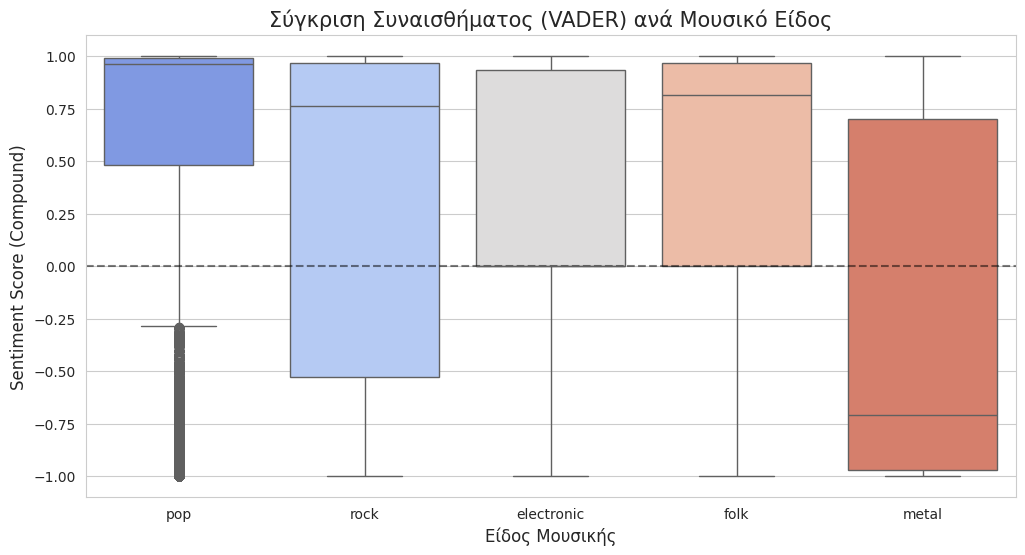

In [16]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def apply_sentiment_analysis(df): 
    analyzer = SentimentIntensityAnalyzer() # Αρχικοποίηση
    def get_vader_score(text):       
        return analyzer.polarity_scores(str(text))['compound']  # Επιστρέφει το score που κυμαίνεται από -1 έως 1

  
    df['sentiment_score'] = df['lyrics'].apply(get_vader_score) # Δημιουργια νεου attribute 
    top_genres = df['top_genres'].value_counts().head(5).index  # Φερε τα τοπ 5 είδη 
    df_subset = df[df['top_genres'].isin(top_genres)]            # Φερε τα τραγούδια 
    
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # Φτιαχνουμε ενα boxplot για να δουμε τη συγκριση
    sns.boxplot(
        data=df_subset, 
        x='top_genres', 
        y='sentiment_score', 
        palette='coolwarm',
        hue='top_genres', 
        legend=False
    )

    plt.title('Σύγκριση Συναισθήματος (VADER) ανά Μουσικό Είδος', fontsize=15)
    plt.xlabel('Είδος Μουσικής', fontsize=12)
    plt.ylabel('Sentiment Score (Compound)', fontsize=12)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5) 
    plt.show()
    
    
    
apply_sentiment_analysis(ds)
    
    
    
    
    
    

### Δ. Ανάλυση Ομοιότητας (Similarity Analysis)

- Σε αυτό το cell επιλέγουμε ένα index ενός τραγουδιού το οποίο το τυπώνουμε 
- Στην συνέχεια έχουμε φτιάξει ένα function το οποίο δέχετε το index του τραγουδιού και επιστρέφει 
τα top τραγούδια που είναι πιο όμοια με βάση 
    1.Τα bert embeddings 
    2.Τα AE embeddings 
που υπολογίσαμε στο προηγούμενο ερώτημα 

- Για να το κάνουμε αυτό υπολογίζουμε το cosine της γωνίας που σχηματίζουν με το target τραγούδι. 
- Στην συνέχεια επιλέγουμε τα top  από το πιο όμοιο lyric_similarity και τα top 5 με το πιο όμοιο 
audio_similariy επιστρέφοντας δύο dataframes τα οποία τα τυπώνουμε 


#### Κάποιες παρατηρήσεις 

- Παρατηρούμε ότι όμοια τραγούδια έχουν υψηλό similaroty στο ήχο και στα lyrics αλλά 
- Αν δύο τραγούδια έχουν πολύ μεγάλο  similarity πχ 0.98 στο audio πιθανότητα πρόκειται για επανεκτέλεση κομματιού ή κλοπή. 
- Τρέχοντας κάποιες φορές αυτό το cell είδαμε και τραγούδια με διαφορετικό id με similarity 1.0 (audio & lyrics )
Άρα κάποια τραγούδια έχουν γραφτεί δύο φορές στο dataset και έχουν το ίδιο id. 


In [17]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import random
from IPython.display import display

"""Αυτό το function δέχετε το index ενός τραγουδιού από το dataset και επιστρέφει 
τα 5 πιο "παράλληλα" τραγούδια βάσει του Cosine Similarity πρώτα με βάση τους στίχους 
και μετά με βάση τον ήχο σε ξεχωριστά pandas dataframes. """

def get_parallel_songs(df, target_index, top_n=5):    

    bert_cols = [col for col in df.columns if col.startswith('bert_feature_')]    # Φέρε τις στήλες που περιέχουν τα  lyric embeddings
    ae_cols = [col for col in df.columns if col.startswith('AE_emb_')]  # Φέρε τις στήλες που περιέχουν τα  audio embeddings
    
   
    all_bert_vectors = df[bert_cols].values    # Φέρε τα lyric embeddings από όλα τα τραγούδια 
    all_ae_vectors = df[ae_cols].values      # Φέρε τα audio embeddings από όλα τα τραγούδια 
    
    target_bert_vector = df.loc[target_index, bert_cols].values.reshape(1, -1)   # Φέρε τα lyric embeddings από το target song 
    target_ae_vector = df.loc[target_index, ae_cols].values.reshape(1, -1)      # Φέρε τα audio embeddings από το target song 
    
    
     # Υπολόγισε τις τιμές των  συνημιτονων της γωνίας που σχηματίζε το target και τα υπόλοιπα διανύσματα 
     # ξεχωριστά για το lyric και για τα audio embeddings για να δούμε πόσο παράλληλα είναι
    sim_lyrics = cosine_similarity(target_bert_vector, all_bert_vectors)[0]
    sim_audio = cosine_similarity(target_ae_vector, all_ae_vectors)[0]
    
    #Βαλτα σε ενα dataframe και υπολόγισε τα 5 πιο παράλληλα διανύσματα για κάθε
    # κατηγορία lyrics και audio ξεχωριστά 
    results_df = df.copy()
    results_df['Lyrics_Similarity'] = sim_lyrics
    results_df['Audio_Similarity'] = sim_audio
    results_df = results_df.drop(index=target_index) # πετάμε το ίδιο το target song  απέξω από το dataframe
    display_cols = ['id', 'top_genres', 'Lyrics_Similarity', 'Audio_Similarity'] 
    top_by_lyrics = results_df.nlargest(top_n, 'Lyrics_Similarity')[display_cols]
    top_by_audio = results_df.nlargest(top_n, 'Audio_Similarity')[display_cols]
    
    return top_by_lyrics, top_by_audio





def pick_random_song(df):
    random_index = random.randint(0, len(df) - 1)
    display_cols = ['id', 'top_genres', 'artist', 'song', 'album_name',	'tags']
    random_song = df.iloc[[random_index]] [display_cols]
    return random_index, random_song


index,song = pick_random_song(bert_autoencoder_ds)
print(f"--- Επιλέχθηκε Τυχαίο Τραγούδι (Index: {index}) ---")
display(song)
similar_lyrics,similar_audio = get_parallel_songs(bert_autoencoder_ds, index, 5)

print("------Top 5 τραγούδια με  το μεγαλύτερο lyric similarity-------")
display(similar_lyrics)
print("---------------------------------------------------------------")
print("------Top 5 τραγούδια με το μεγαλύτερο audio similarity--------")
display(similar_audio)
print("---------------------------------------------------------------")




--- Επιλέχθηκε Τυχαίο Τραγούδι (Index: 12715) ---


,id,top_genres,artist,song,album_name,tags
12715,D5YUDK4YInJnzktj,rock,Foo Fighters,Bridge Burning,Wasting Light,"alternative rock,rock,post-grunge,alternative,..."


------Top 5 τραγούδια με  το μεγαλύτερο lyric similarity-------


,id,top_genres,Lyrics_Similarity,Audio_Similarity
39533,ebTaNj3pn2SPzia7,pop,0.721818,0.882130
38294,dJME8EeUycQLt5Xg,rock,0.702641,0.856124
40227,fIfdkBVUdgkNpyjx,rock,0.702641,0.854415
14501,EvRN6zjYtzakcnHN,pop,0.700510,0.867164
43994,j3SjCQREHPe8jEKG,pop,0.700510,0.925278


---------------------------------------------------------------
------Top 5 τραγούδια με το μεγαλύτερο audio similarity--------


,id,top_genres,Lyrics_Similarity,Audio_Similarity
2183,2FBlsyelm7CeXbTF,rock,0.407654,0.963696
19760,KJvhhaBq2eJ8N0TG,rock,0.386402,0.960369
40285,fLdN0aWckmSJjWjq,rock,0.545641,0.959140
54784,uAGy5eaqTCm0Z7pZ,rock,0.396197,0.957802
19293,JpflngK6uBo9N0Kw,rock,0.509625,0.957470


---------------------------------------------------------------


# Μέρος B
- Εδώ έχουμε το δεύτερο μέρος της εργασίας το οποίο το συνεχίζουμε από το πρώτο στο ίδιο notebook


## Προεπεξεργασία 

- Αρχικά κάνουμε ένα split στο dataset για να το χωρίσουμε σε train set και test set αφού δεν έχουμε κάποιο test set από την αρχή
- Επίσης πρέπει να ορίσουμε και το target label y το οποίο είναι το top_genre που έχουμε συζητήσει στο πρώτο μέρος  
καθώς έχουμε ένα multiclass classification πρόβλημα και άρα κάθε sample πρέπει να ανήκει σε ακριβώς μια κατηγορία πράγμα 
για το οποίο φροντίζει το top_genre.    
- Επίσης παίρνουμε τα bert features και autoencoded audio features γιατί θα τα χρειαστούμε.  




In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

""" Utility function που κάνει split το dataset σε train set και test set και ορίζει το target label 
για αυτά τα datasets """
def process_dataset(df, test_size, random_state, target_label):
    X = df.drop(columns=[target_label])
    y = df[target_label]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test 


X_train, X_test, y_train, y_test = process_dataset(bert_autoencoder_ds, 0.2, 42, 'top_genres')
bert_columns = [col for col in X_train.columns if col.startswith('bert_feature_')]
ae_colums = [col for col in X_train.columns if col.startswith('AE_emb_')]




  

### Σημαντική Παρατήρηση σχετικά με το scaling 
- Στο πρώτο μέρος της άσκησης εξηγούμε αναλυτικά γιατί ένα πιθανό scaling των δεδομένων σε αυτό το σημείο και 
γενικά πριν το split (ή κατα το πρώτο μέρος της άσκησης) μπορεί να προκαλέσει ένα πιθανό data leak. 

- Μεταφέρουμε αυτή την παρατήρηση και στο δεύτερο μέρος της άσκησης καθώς και έναν σχετικό σύνδεσμο για το πως 
πρέπει να χρησιμοποιήσουμε το library της scikit για να αποφύγουμε αυτό το πρόβλημα 

-  Ας πούμε ότι χρησιμοποιούμε τη συνάρτηση της βιβλιοθήκης StandardScaler, η οποία χρησιμοποιεί  standardization για να εκτελέσει την κλιμάκωση, οπότε η κανονικοποιημένη τιμή είναι:
                            $$z = \frac{x - \mu}{\sigma}$$
όπου $\mu = \mathbb{E}[X]$ η μέση τιμή  και $\sigma^2 = \mathbb{V}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$ η τυπική απόκλιση (σ)

- Το πρόβλημα είναι ότι στη συνέχεια στο δεύτερο μέρος  πρέπει να εκτελέσουμε k-cross validation. 
  Άρα αν κάνουμε prescaling από τώρα τα χαρακτηριστικά μας, χρησιμοποιούμε την μέση τιμή $\mu_{train}$ 
  και την τυπική απόκλιση $\sigma_{train}$ του train set.
- Αργότερα όμως εκτελούμε k-cross validation πράγμα που σημαίνει ότι επιλέγουμε ένα υποσύνολο του train set για να παίξει 
το ρόλο του validation set

- Αυτό όμως είναι κλεψιά  (cheating) επειδή (άθελά μας) έχουμε "πικάρει" το validation set με τους μέσους όρους ( και ακόμα χειρότερα ίσως το test_set αν παμε να το κανουμε σπλιτ) , 
υπονομεύοντας τα αποτελέσματα του validation (ή του test) και προκαλώντας μια πιθανή διαρροή δεδομένων (data leak).Αυτό μπορεί να διορθωθεί αν πχ δώσουμε τον έλεγχο στο library δημιουργώντας
ενα pipeline εφαρμοζοντας τον scaler  εκει κάπως έτσι πχ 

https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#sphx-glr-auto-examples-compose-plot-column-transformer-mixed-types-py

## SVM 

- Ο πρώτος classifier που αποφασίσαμε να εκπαιδεύσουμε είναι ο SVM (Support Vector Machines) για τα lyric και τα audio features ξεχωριστά μετά κάνουμε fusion
early και late και στην συνέχεια οπτικοποιούμε και αναλύουμε τα αποτελέσματά μας.

- 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report



preprocessor = ColumnTransformer(
    transformers=[
        ('scale_text', StandardScaler(), bert_columns)
    ],
    remainder='drop' 
)

# 4. Δημιουργία του Pipeline
# Συνδέουμε τον preprocessor με τον ταξινομητή SVM
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

# 5. Εκπαίδευση του Μοντέλου
print("Εκπαίδευση του Model A (Text-only SVM)...")
svm_pipeline.fit(X_train, y_train)

# 6. Πρόβλεψη και Αξιολόγηση στο Test set
y_pred = svm_pipeline.predict(X_test)

print("\n--- Αποτελέσματα Αξιολόγησης (Model A) ---")
print(classification_report(y_test, y_pred))

Εκπαίδευση του Model A (Text-only SVM)...
